In [2]:
import openml 
from openml import datasets, tasks, runs
import numpy as np
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import pickle
import os
import re
import statistics as stat
from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
import sklearn.metrics
from sklearn import linear_model
from sklearn import svm
from sklearn import gaussian_process
from sklearn import tree
from sklearn import ensemble
from sklearn import neural_network
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer

In [46]:
#flows = openml.flows.list_flows(tag="sklearn",output_format="dataframe")
flows = openml.flows.list_flows(tag="sklearn")
skflows = {}
for fid, fval in flows.items():
#    print(fid,"->",fval["full_name"])
    skflows[fid] = fval["full_name"]
#skflows
pd.DataFrame.from_dict(skflows, orient='index')


/var/folders/v4/mgpzl55x2p907x9g5_5hh62h0000gn/T/ipykernel_73050/2760664400.py:2: FutureWarning: Support for `output_format` of 'dict' will be removed in 0.15 and pandas dataframes will be returned instead. To ensure your code will continue to work, use `output_format`='dataframe'.
  flows = openml.flows.list_flows(tag="sklearn")


,0
6751,sklearn.dummy.DummyClassifier(2)
6752,__main__.PythonChallengeClassifier(1)
6756,sklearn.tree.tree.ExtraTreeClassifier(2)
6757,sklearn.pipeline.Pipeline(Imputer=sklearn.prep...
6758,sklearn.preprocessing.imputation.Imputer(5)
...,...
126348,fractal.sklearn_wrapper.HenryLawWrapper_E50_d1...
126349,fractal.sklearn_wrapper.HenryLawWrapper_E100_2...
126350,fractal.sklearn_wrapper.HenryLawWrapper_E50_21...
126351,fractal.sklearn_wrapper.HenryLawWrapper_E1_ebc...


In [47]:
print(len(flows))

10342


In [48]:
flows_all = openml.flows.list_flows()
print(len(flows_all))

/var/folders/v4/mgpzl55x2p907x9g5_5hh62h0000gn/T/ipykernel_73050/1589771321.py:1: FutureWarning: Support for `output_format` of 'dict' will be removed in 0.15 and pandas dataframes will be returned instead. To ensure your code will continue to work, use `output_format`='dataframe'.
  flows_all = openml.flows.list_flows()


123520


In [49]:
def cleanme(s):
    tab_to_replace = {'.': ' ',
                   '(': ' ',
                   ')': ' ',
                   '_': ' ',
                      ',': ' ',
                     '=': ' '}
    s1 = s.translate(str.maketrans(tab_to_replace))
    s1 = re.sub("\s[0-9a-fA-F]+\s"," ",s1)
    s1 = re.sub("\d+","",s1)
    s1 = re.sub("TEST\S+"," ",s1)
    s1 = re.sub("\sCx\S+"," ",s1)
    return(s1)

corpus1 = list(skflows.values())
corpus = [cleanme(x) for x in corpus1]


#print(corpus)




In [100]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
Xa = model.encode(corpus)


In [96]:
v = TfidfVectorizer()
v2 = TfidfVectorizer(min_df=0.1, max_df=0.9)
v3 = TfidfVectorizer(ngram_range=(1,2))
v4 = TfidfVectorizer(ngram_range=(1,2), min_df=0.1, max_df=0.9)
v5 = CountVectorizer()
v6 = CountVectorizer(min_df=0.1, max_df=0.9)
v7 = HashingVectorizer(n_features=500)
v8 = HashingVectorizer(n_features=1000)
v9 = CountVectorizer(ngram_range=(1,2))

X = v.fit_transform(corpus)
X2 = v2.fit_transform(corpus)
X3 = v3.fit_transform(corpus)
X4 = v4.fit_transform(corpus)
X5 = v5.fit_transform(corpus)
X6 = v6.fit_transform(corpus)
X7 = v7.fit_transform(corpus)
X8 = v8.fit_transform(corpus)
X9 = v9.fit_transform(corpus)


In [118]:

#print(v.idf_)
embed = np.array(v.get_feature_names_out().tolist())
embed2 = np.array(v2.get_feature_names_out()) 
embed3 = np.array(v3.get_feature_names_out()) 
embed4 = np.array(v4.get_feature_names_out())
embed5 = np.array(v5.get_feature_names_out()) 
embed6 = np.array(v6.get_feature_names_out()) 
embed7 = ['HASH']* v7.n_features
embed8 = ['HASH']* v8.n_features
embed9 = np.array(v9.get_feature_names_out()) 
embeda = ['LLM']*len(Xa[0])

print(len(embed))
print(len(embed2))
print(len(embed3))
print(len(embed4))
print(len(embed5))
print(len(embed6))
print(len(embed7))
print(len(embed8))
print(len(embed9))
print(len(embeda))

#count_list = X2.toarray().sum(axis=0)
#word_list = v2.get_feature_names_out() 

#print(word_list)

#cd = dict(zip(word_list,count_list))
#cds = dict(sorted(cd.items(), key=lambda item: item[1]))
#
#print(cds)

#df = pd.DataFrame(X[0].T.todense(), index=v.get_feature_names_out(), columns=["count"])
#df = df.sort_values('count', ascending=False)
#df.to_csv('Output.csv', index = False)
#df = pd.DataFrame(X[0].T.todense(), index=v.get_feature_names_out(), columns=["TF-IDF"])
#df = df.sort_values('TF-IDF', ascending=False)
#print (df.head(100))

#v.get_feature_names_out()


491
17
2027
36
491
17
500
1000
2027
394


In [101]:
def doflow(A) :
    flows = {}
    i=0
    for fid in skflows:
        flows[fid] = A[i].tolist()
        i+=1
    return flows

In [102]:
flows = doflow(X.toarray())
flows2 = doflow(X2.toarray())
flows3 = doflow(X3.toarray())
flows4 = doflow(X4.toarray())
flows5 = doflow(X5.toarray())
flows6 = doflow(X6.toarray())
flows7 = doflow(X7.toarray())
flows8 = doflow(X8.toarray())
flows9 = doflow(X9.toarray())
flowsa = doflow(Xa)



In [103]:
x = {}
evaluations = {}
taskdata = {}
s=0
benchmark_suite = openml.study.get_suite('OpenML-CC18') # obtain the benchmark suite
#benchmark_suite.tasks
for task_id in benchmark_suite.tasks:  # iterate over all tasks

    task = openml.tasks.get_task(task_id)  # download the OpenML task
    #print(task_id,': ',task.dataset_id)
    evaluations[task_id] = openml.evaluations.list_evaluations(tasks=[task_id],function='predictive_accuracy', size=None)
    s = s + len(evaluations[task_id])
    print(task_id, len(evaluations[task_id]))
    taskdata[task_id] = task.dataset_id
print(s)


3 173294
6 34713
11 24519
12 23084
14 23736
15 24293
16 24209
18 21518
22 20022
23 18790
28 21470
29 20979
31 415095
32 23397
37 131146
43 99156
45 20332
49 111923
53 25056
219 77384
2074 21138
2079 19951
3021 16459
3022 18698
3481 16428
3549 23333
3560 19560
3573 13147
3902 112333
3903 142734
3904 18787
3913 173605


KeyboardInterrupt: 

In [ ]:
with open("taskdata.txt", "wb") as f:
    pickle.dump(taskdata, f)


In [13]:
ewf = {}
for ti,tv in evaluations.items():
    ewf[ti] = {}
#    print(ti,":")
    for e,val in tv.items():
        if val.flow_id in ewf[ti]:
            ewf[ti][val.flow_id].append(val.value)
        else:
            ewf[ti][val.flow_id] = [val.value]
#            print (val.flow_id)
#    s = pd.Series(eee)
#    print(s)

#    print(s.describe())

In [14]:
vse_a = []
vse_i = []
for ti in benchmark_suite.tasks:
    for d in ewf[ti]:
        #print(ewf[ti][d])
        vse_i.extend([ti]*len(ewf[ti][d]))
        vse_a.extend(ewf[ti][d])
        #s = pd.Series(ewf[ti][d])
vse = pd.DataFrame({'id': vse_i, 'acc':vse_a})


<Axes: xlabel='acc', ylabel='id'>

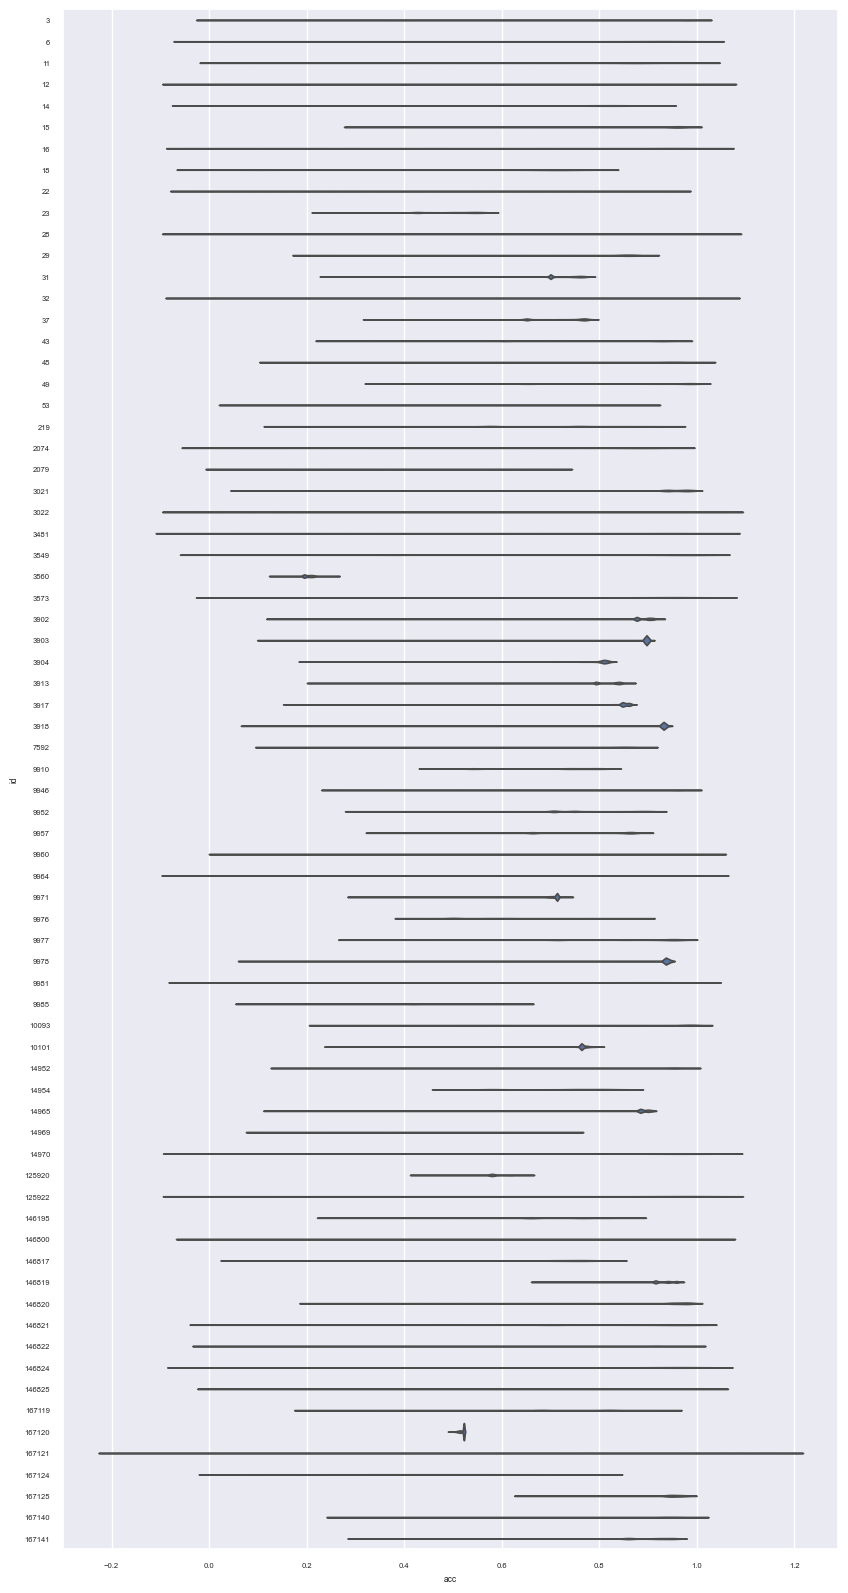

In [15]:
plt.figure(figsize=(10, 20))
seaborn.set(font_scale=0.5)
#seaborn.violinplot(data=vse, orient="y", x="acc", y="id", fill=False)
seaborn.violinplot(data=vse, orient="y", x="acc", y="id", inner=None)

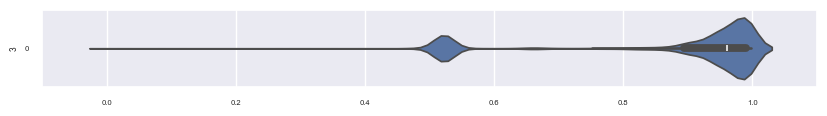

<Figure size 640x480 with 0 Axes>

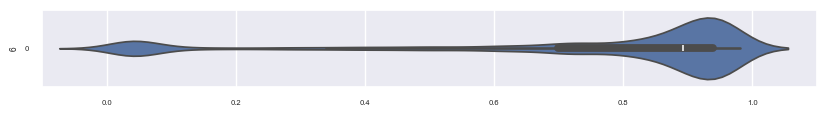

<Figure size 640x480 with 0 Axes>

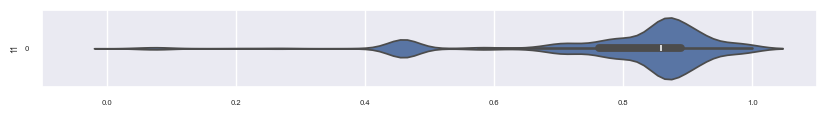

<Figure size 640x480 with 0 Axes>

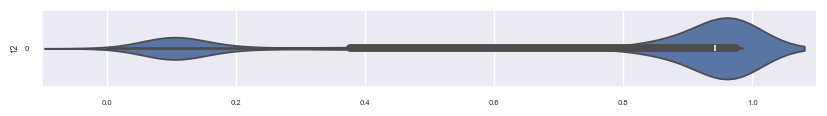

<Figure size 640x480 with 0 Axes>

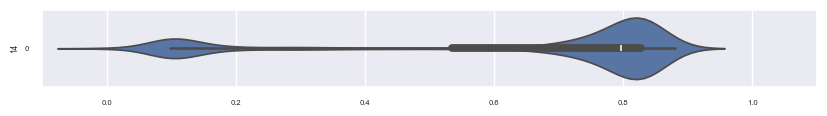

<Figure size 640x480 with 0 Axes>

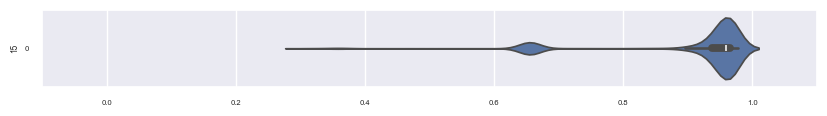

<Figure size 640x480 with 0 Axes>

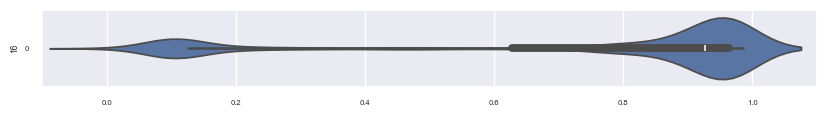

<Figure size 640x480 with 0 Axes>

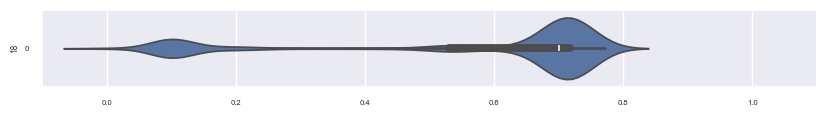

<Figure size 640x480 with 0 Axes>

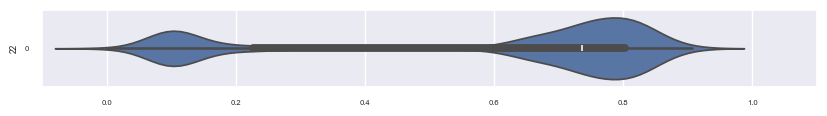

<Figure size 640x480 with 0 Axes>

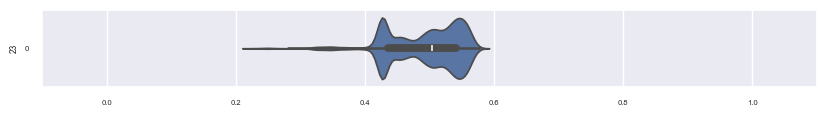

<Figure size 640x480 with 0 Axes>

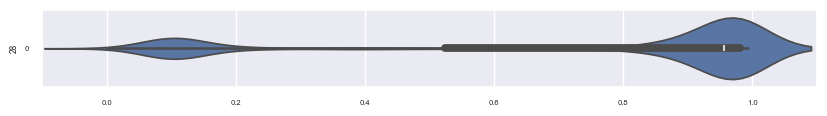

<Figure size 640x480 with 0 Axes>

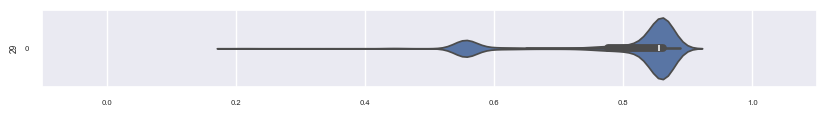

<Figure size 640x480 with 0 Axes>

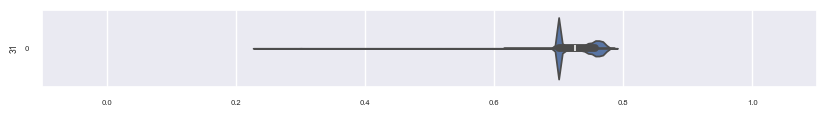

<Figure size 640x480 with 0 Axes>

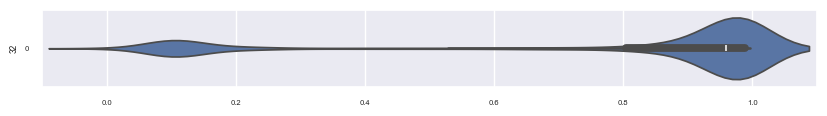

<Figure size 640x480 with 0 Axes>

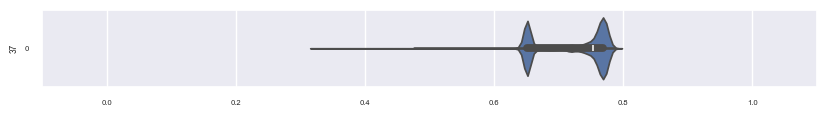

<Figure size 640x480 with 0 Axes>

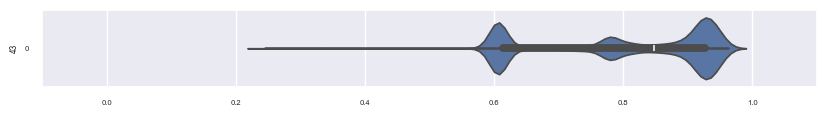

<Figure size 640x480 with 0 Axes>

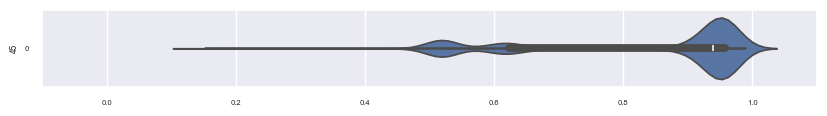

<Figure size 640x480 with 0 Axes>

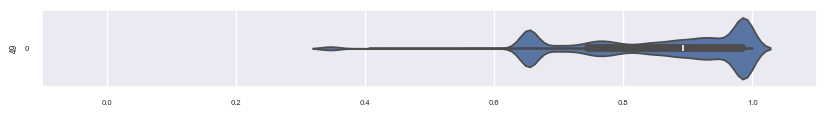

<Figure size 640x480 with 0 Axes>

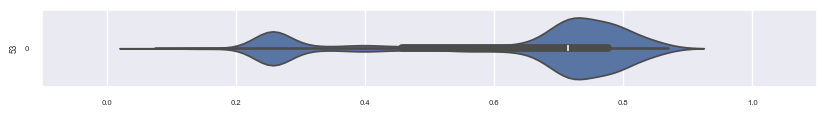

<Figure size 640x480 with 0 Axes>

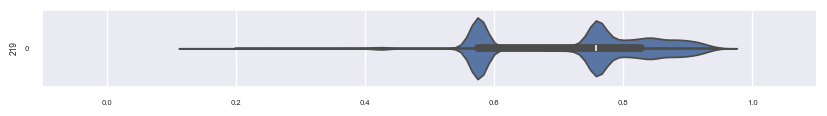

<Figure size 640x480 with 0 Axes>

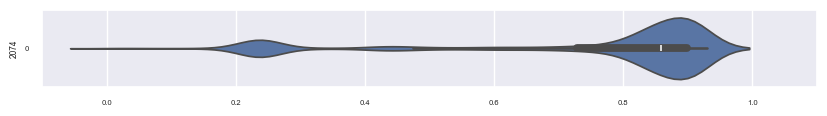

<Figure size 640x480 with 0 Axes>

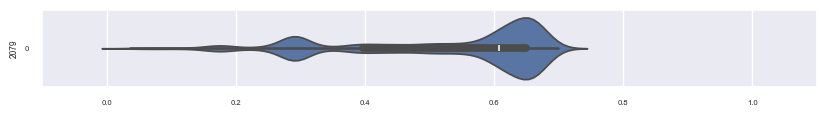

<Figure size 640x480 with 0 Axes>

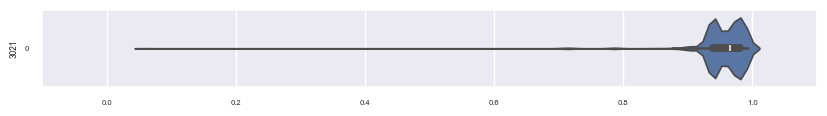

<Figure size 640x480 with 0 Axes>

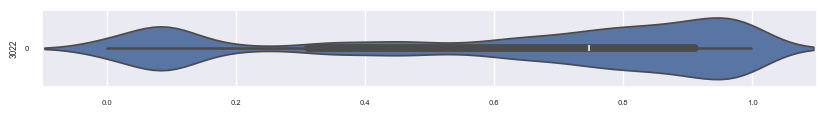

<Figure size 640x480 with 0 Axes>

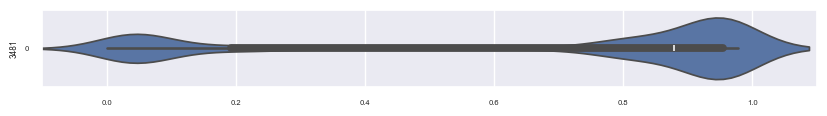

<Figure size 640x480 with 0 Axes>

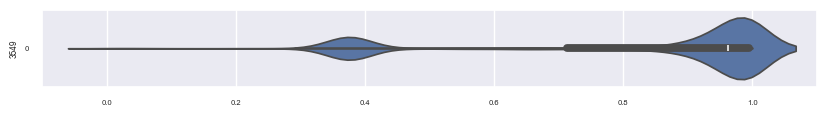

<Figure size 640x480 with 0 Axes>

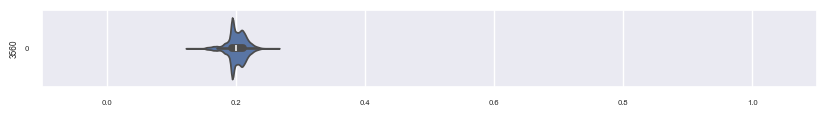

<Figure size 640x480 with 0 Axes>

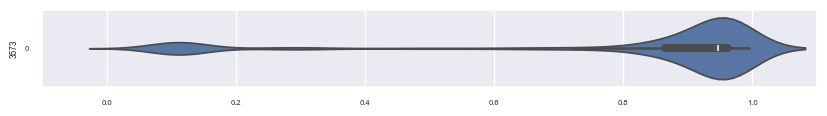

<Figure size 640x480 with 0 Axes>

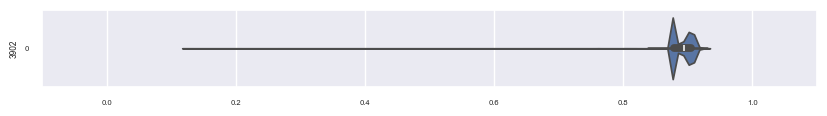

<Figure size 640x480 with 0 Axes>

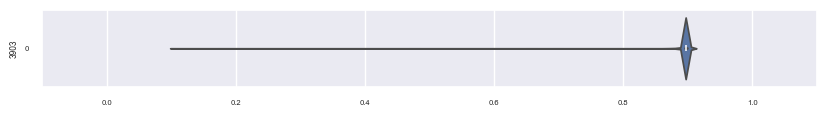

<Figure size 640x480 with 0 Axes>

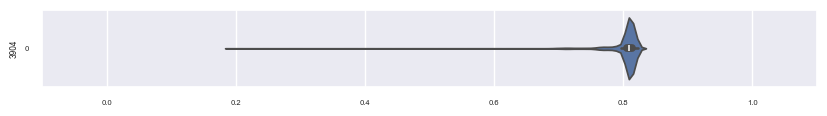

<Figure size 640x480 with 0 Axes>

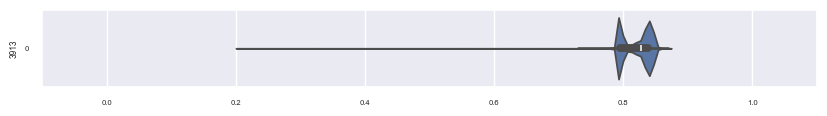

<Figure size 640x480 with 0 Axes>

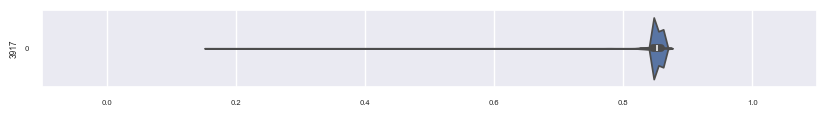

<Figure size 640x480 with 0 Axes>

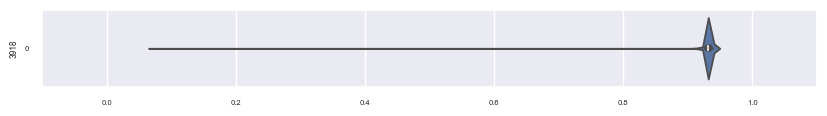

<Figure size 640x480 with 0 Axes>

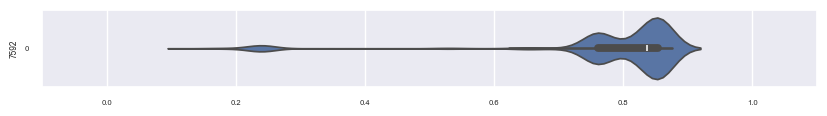

<Figure size 640x480 with 0 Axes>

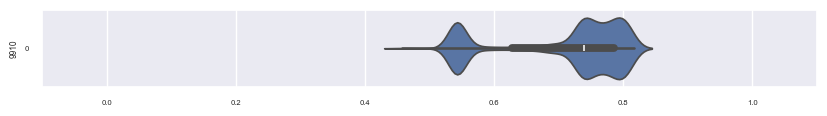

<Figure size 640x480 with 0 Axes>

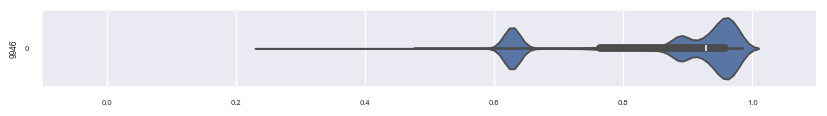

<Figure size 640x480 with 0 Axes>

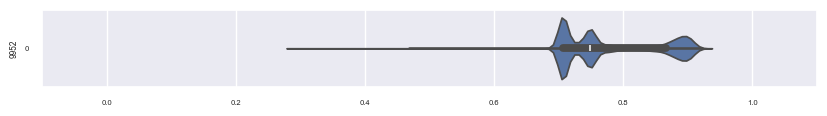

<Figure size 640x480 with 0 Axes>

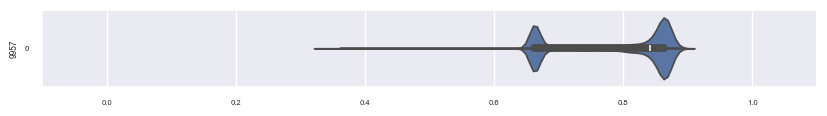

<Figure size 640x480 with 0 Axes>

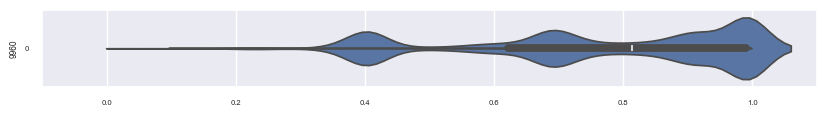

<Figure size 640x480 with 0 Axes>

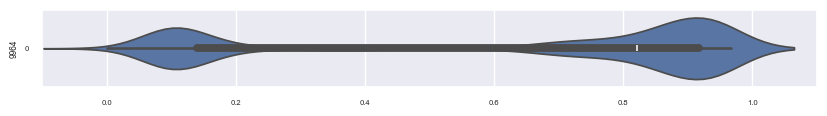

<Figure size 640x480 with 0 Axes>

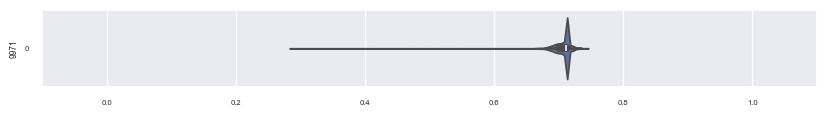

<Figure size 640x480 with 0 Axes>

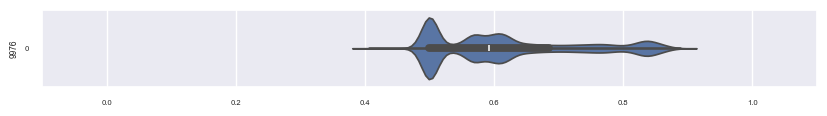

<Figure size 640x480 with 0 Axes>

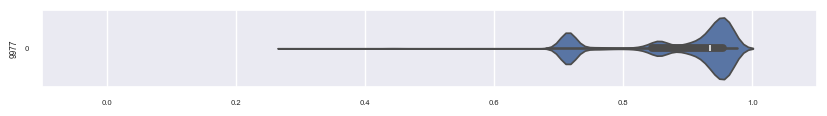

<Figure size 640x480 with 0 Axes>

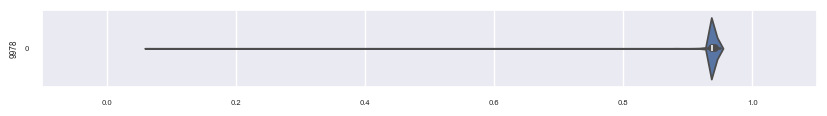

<Figure size 640x480 with 0 Axes>

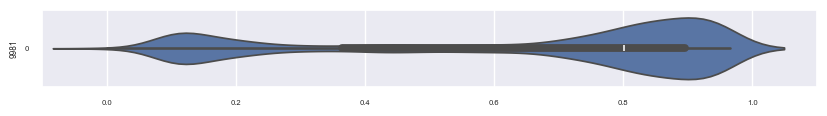

<Figure size 640x480 with 0 Axes>

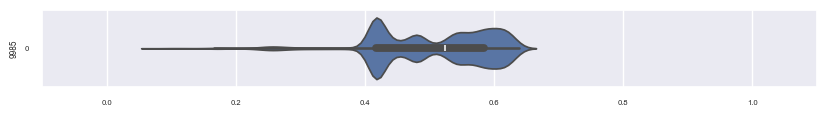

<Figure size 640x480 with 0 Axes>

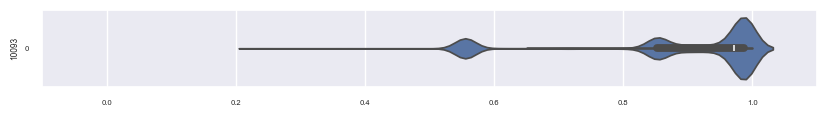

<Figure size 640x480 with 0 Axes>

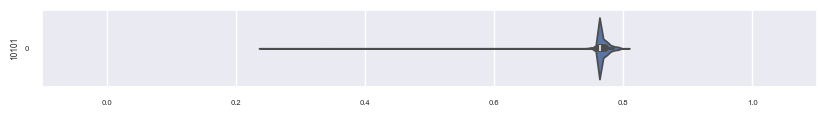

<Figure size 640x480 with 0 Axes>

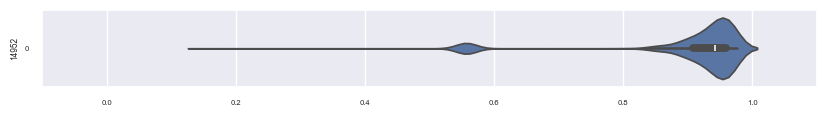

<Figure size 640x480 with 0 Axes>

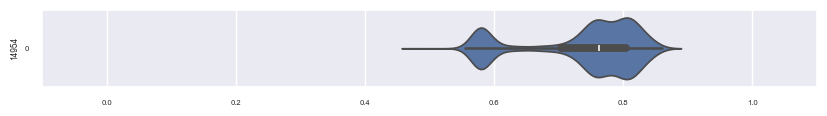

<Figure size 640x480 with 0 Axes>

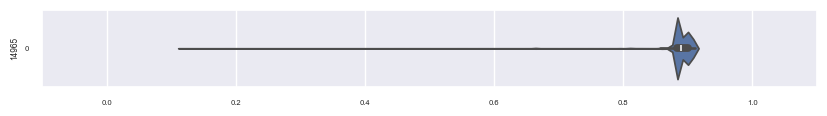

<Figure size 640x480 with 0 Axes>

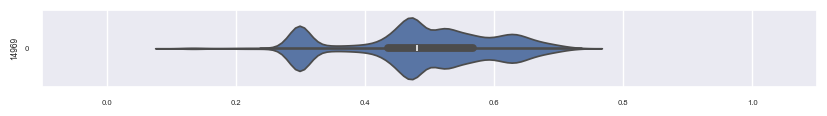

<Figure size 640x480 with 0 Axes>

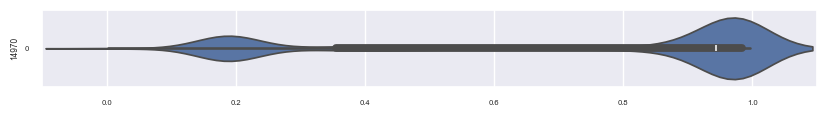

<Figure size 640x480 with 0 Axes>

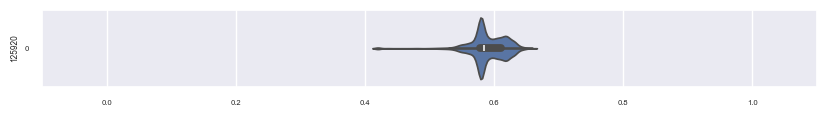

<Figure size 640x480 with 0 Axes>

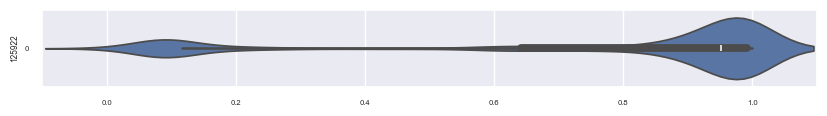

<Figure size 640x480 with 0 Axes>

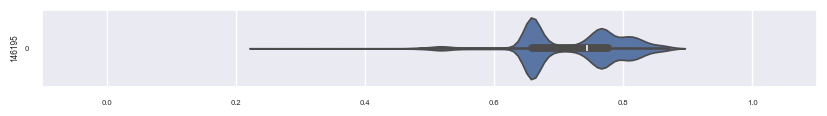

<Figure size 640x480 with 0 Axes>

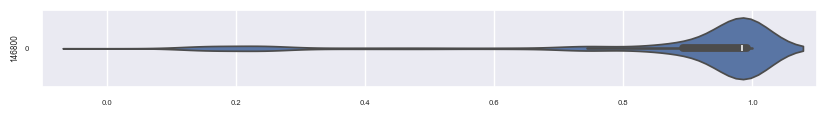

<Figure size 640x480 with 0 Axes>

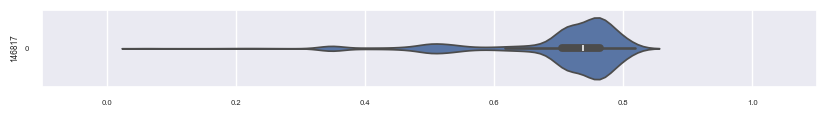

<Figure size 640x480 with 0 Axes>

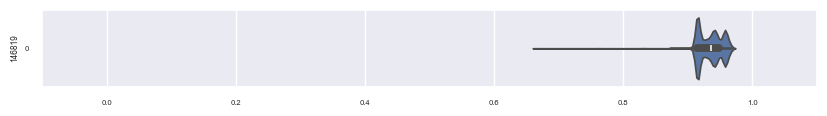

<Figure size 640x480 with 0 Axes>

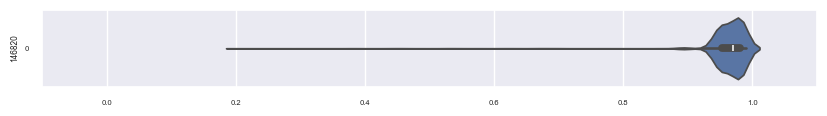

<Figure size 640x480 with 0 Axes>

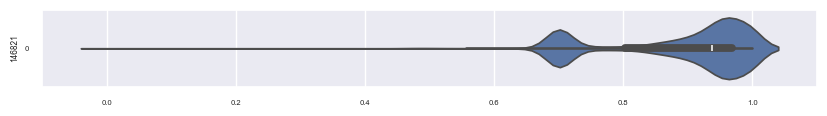

<Figure size 640x480 with 0 Axes>

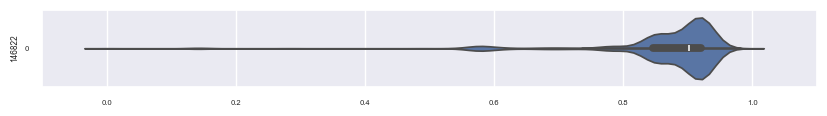

<Figure size 640x480 with 0 Axes>

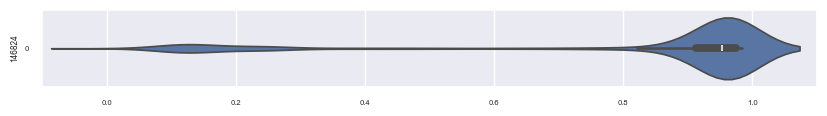

<Figure size 640x480 with 0 Axes>

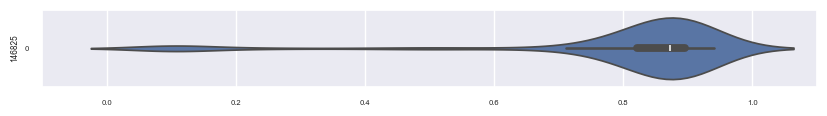

<Figure size 640x480 with 0 Axes>

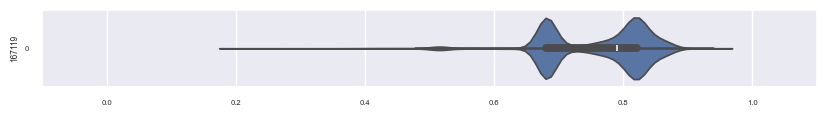

<Figure size 640x480 with 0 Axes>

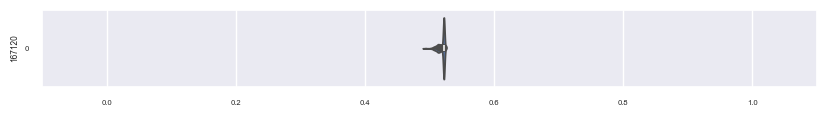

<Figure size 640x480 with 0 Axes>

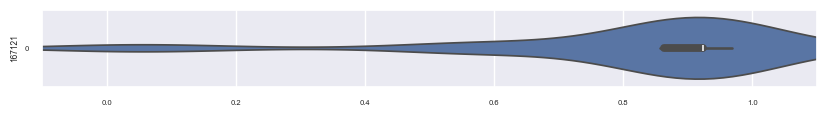

<Figure size 640x480 with 0 Axes>

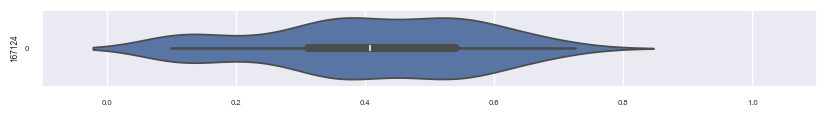

<Figure size 640x480 with 0 Axes>

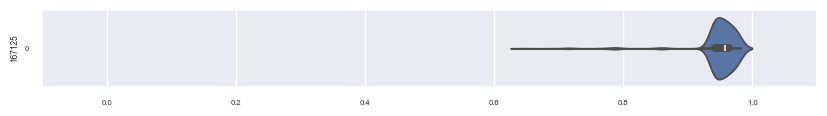

<Figure size 640x480 with 0 Axes>

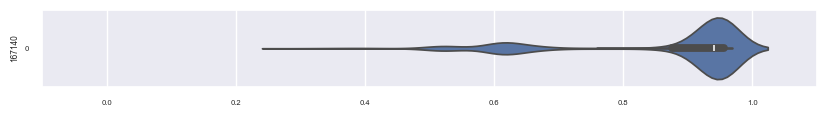

<Figure size 640x480 with 0 Axes>

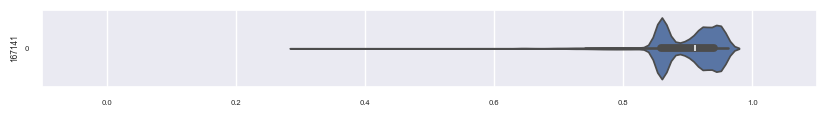

<Figure size 640x480 with 0 Axes>

In [16]:
vse_a = []
vse_i = []



for ti in benchmark_suite.tasks:
    mala = []
    for d in ewf[ti]:
        mala.extend(ewf[ti][d])
        #print(ewf[ti][d])
        vse_i.extend([ti]*len(ewf[ti][d]))
        vse_a.extend(ewf[ti][d])
        #s = pd.Series(ewf[ti][d])
#vse = pd.DataFrame({'id': vse_i, 'acc':vse_a})
    vse = pd.DataFrame(mala)
    plt.figure(figsize=(10, 1))
    plt.ylabel(ti)
    plt.xlim(-0.1, 1.1)
    p = seaborn.violinplot(data=vse,orient="y")
    plt.show(p)
    plt.savefig(f"{ti:06}"+".png")

    
    


In [17]:
#runs = openml.runs.list_runs(task=[task_id], tag="Sklearn_0.22.1.", size=100)
runs = openml.runs.list_runs(task=[task_id], size=None)

print(len(runs))

/var/folders/v4/mgpzl55x2p907x9g5_5hh62h0000gn/T/ipykernel_82886/670544045.py:2: FutureWarning: Support for `output_format` of 'dict' will be removed in 0.15 and pandas dataframes will be returned instead. To ensure your code will continue to work, use `output_format`='dataframe'.
  runs = openml.runs.list_runs(task=[task_id], size=None)


5454


In [18]:
openml.runs.get_run(1847764)

OpenML Run
Uploader Name...................: Jan van Rijn
Uploader Profile................: https://www.openml.org/u/1
Metric..........................: None
Local Result - Accuracy (+- STD): 0.9055 +- 0.0151
Run ID..........................: 1847764
Run URL.........................: https://www.openml.org/r/1847764
Task ID.........................: 3
Task Type.......................: Supervised Classification
Task URL........................: https://www.openml.org/t/3
Flow ID.........................: 5501
Flow Name.......................: sklearn.neighbors.classification.KNeighborsClassifier(6)
Flow URL........................: https://www.openml.org/f/5501
Setup ID........................: 29016
Setup String....................: None
Dataset ID......................: 3
Dataset URL.....................: https://www.openml.org/d/3

In [19]:
from tqdm import tqdm
goodruns = []
for i in tqdm(runs):
    run = openml.runs.get_run(i)
    if "sklearn" in run.flow_name:
        goodruns.append(i)
print(len(goodruns))

100%|██████████████████████████████████████| 5454/5454 [00:11<00:00, 489.85it/s]

5447


In [20]:
data = openml.datasets.list_datasets()
#data

/var/folders/v4/mgpzl55x2p907x9g5_5hh62h0000gn/T/ipykernel_82886/1503615678.py:1: FutureWarning: Support for `output_format` of 'dict' will be removed in 0.15 and pandas dataframes will be returned instead. To ensure your code will continue to work, use `output_format`='dataframe'.
  data = openml.datasets.list_datasets()


In [21]:
columns = ['MajorityClassSize',
           'MaxNominalAttDistinctValues',
           'MinorityClassSize',
           'NumberOfClasses',
           'NumberOfFeatures',
           'NumberOfInstances',
           'NumberOfInstancesWithMissingValues',
           'NumberOfMissingValues',
           'NumberOfNumericFeatures',
           'NumberOfSymbolicFeatures']
dsets = {}
for dind, dval in data.items():
#    print(dind)
    l = []
    for c in columns:
        if c in dval:
            l.append(dval[c])
        else:
            l.append(0.0)
    dsets[dind] = l

len(dsets)


6377

In [22]:
with open("dsets.txt", "wb") as file1:
    pickle.dump(dsets, file1)
with open("ewf.txt", "wb") as file1:
    pickle.dump(ewf, file1)
with open("t2d.txt", "wb") as file1:
    pickle.dump(taskdata, file1)
with open("flows.txt", "wb") as file1:
    pickle.dump(flows, file1)
with open("flows2.txt", "wb") as file1:
    pickle.dump(flows2, file1)
with open("flows3.txt", "wb") as file1:
    pickle.dump(flows3, file1)
with open("flows4.txt", "wb") as file1:
    pickle.dump(flows4, file1)
with open("flows5.txt", "wb") as file1:
    pickle.dump(flows5, file1)
with open("flows6.txt", "wb") as file1:
    pickle.dump(flows6, file1)  
with open("flows7.txt", "wb") as file1:
    pickle.dump(flows7, file1)
with open("flows8.txt", "wb") as file1:
    pickle.dump(flows8, file1)  
with open("flows9.txt", "wb") as file1:
    pickle.dump(flows9, file1)  
with open("flowsa.txt", "wb") as file1:
    pickle.dump(flowsa, file1)  


In [3]:
with open('ewf.txt', 'rb') as f:
    ewf = pickle.load(f)
with open('t2d.txt', 'rb') as f:
    t2d = pickle.load(f)
with open('dsets.txt', 'rb') as f:
    dsets = pickle.load(f)
with open('flows.txt', 'rb') as f:
    flows = pickle.load(f)
with open('flows2.txt', 'rb') as f:
    flows2 = pickle.load(f)
with open('flows3.txt', 'rb') as f:
    flows3 = pickle.load(f)
with open('flows4.txt', 'rb') as f:
    flows4 = pickle.load(f)
with open('flows5.txt', 'rb') as f:
    flows5 = pickle.load(f)
with open('flows6.txt', 'rb') as f:
    flows6 = pickle.load(f)
with open('flows7.txt', 'rb') as f:
    flows7 = pickle.load(f)
with open('flows8.txt', 'rb') as f:
    flows8 = pickle.load(f)
with open('flows9.txt', 'rb') as f:
    flows9 = pickle.load(f)
with open('flowsa.txt', 'rb') as f:
    flowsa = pickle.load(f)

In [105]:
len(ewf)

72

In [4]:
A = []
for key, value in dsets.items():
    A.append(value)
scaler = MinMaxScaler()
B = scaler.fit_transform(A)
i = 0;
for key in dsets:
    dsets[key] = list(B[i])
    i += 1
#dsets   

In [5]:
def up_quartile(data):
    data.sort()               
    half_list = int(len(data)//2)
    upper_quartile = stat.median(data[-half_list])
    return upper_quartile
                                 
#    lower_quartile = stat.median(data[:half_list])
#    print("Lower Quartile: "+str(lower_quartile))
#    print("Upper Quartile: "+str(upper_quartile))
#    print("Interquartile Range: "+str(upper_quartile-lower_quartile)

In [6]:
def makexy(flows):
    X = []
    Y = []
    for ti, tv in ewf.items():
#        print (ti)
        for fi, fv in tv.items():
            if fi in flows:
#            print(fi, len(fv))
                rx = []
                rx.extend(dsets[t2d[ti]])
                rx.extend(flows[fi])
                X.append(rx)
                s = pd.Series(fv)
                q3 = s.quantile(0.75)
                qmax = s.max()
                Y.append(qmax)
    return X, Y

In [7]:

X, Y = makexy(flows)
X2, Y2 = makexy(flows2)
X3, Y3 = makexy(flows3)
X4, Y4 = makexy(flows4)
X5, Y5 = makexy(flows5)
X6, Y6 = makexy(flows6)
X7, Y7 = makexy(flows7)
X8, Y8 = makexy(flows8)
X9, Y9 = makexy(flows9)
Xa, Ya = makexy(flowsa)

In [8]:
len(X[2])

501

In [9]:
columns = ['D MajorityClassSize',
           'D MaxNominalAttDistinctValues',
           'D MinorityClassSize',
           'D NumberOfClasses',
           'D NumberOfFeatures',
           'D NumberOfInstances',
           'D NumberOfInstancesWithMissingValues',
           'D NumberOfMissingValues',
           'D NumberOfNumericFeatures',
           'D NumberOfSymbolicFeatures']



In [10]:
print(len(X))
print(len(flows))
print(len(columns))
print(len(embed))


7657
10341
10


NameError: name 'embed' is not defined

In [11]:
#X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=.1, random_state=42)
kf = RepeatedKFold(n_splits=10, n_repeats=10,random_state=42)
sc_r2 = make_scorer(r2_score)
sc_ma = make_scorer(mean_absolute_error)
sc_ms = make_scorer(mean_squared_error)
#for train_index, test_index in kf.split(X):
    




In [12]:
reg = ensemble.GradientBoostingRegressor()
#reg = ensemble.HistGradientBoostingRegressor()

#reg = ensemble.RandomForestRegressor()

#reg = linear_model.LinearRegression()

#reg = gaussian_process.GaussianProcessRegressor()

#reg = tree.DecisionTreeRegressor()


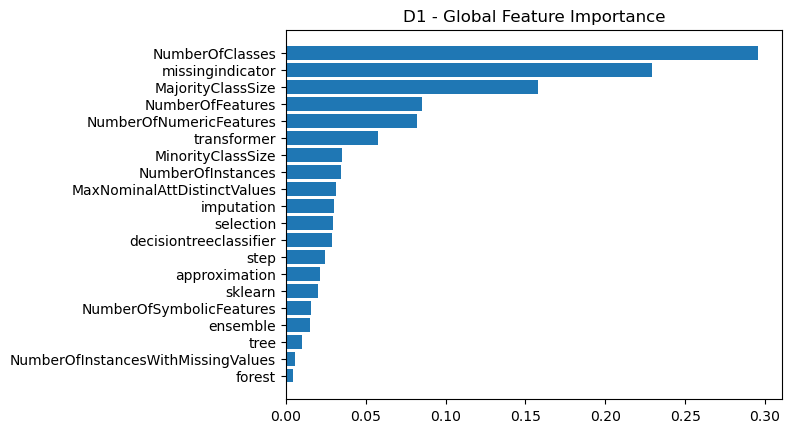

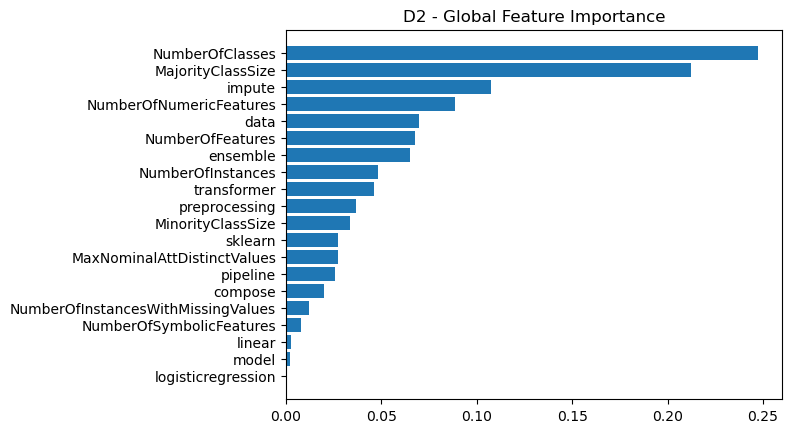

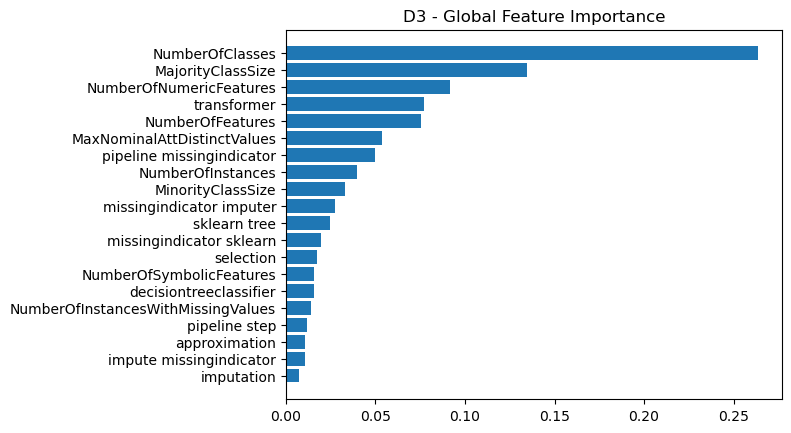

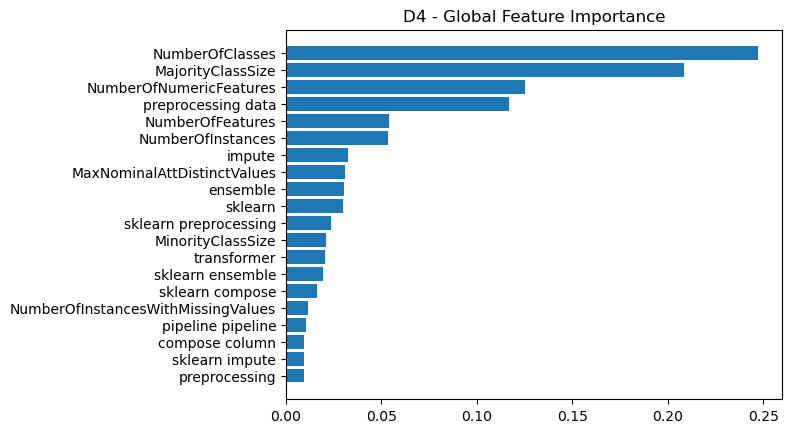

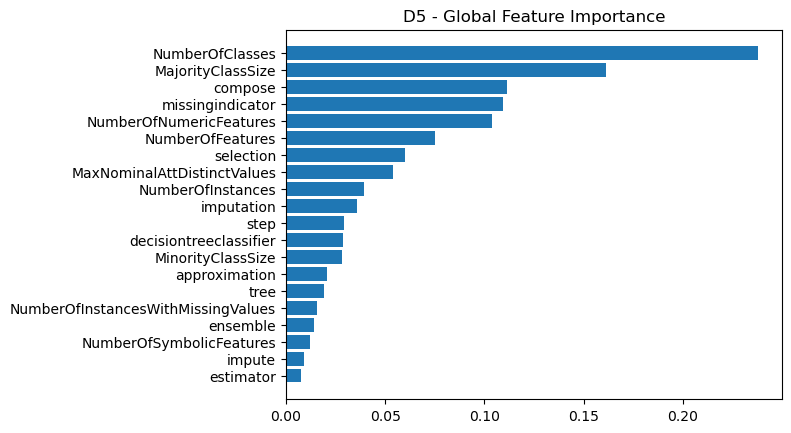

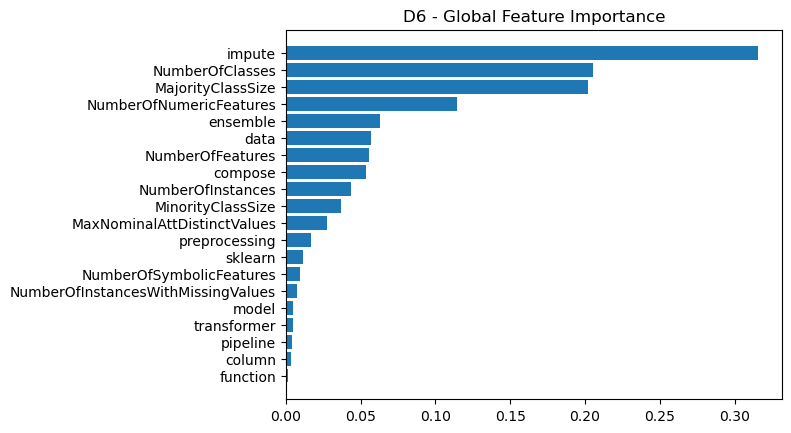

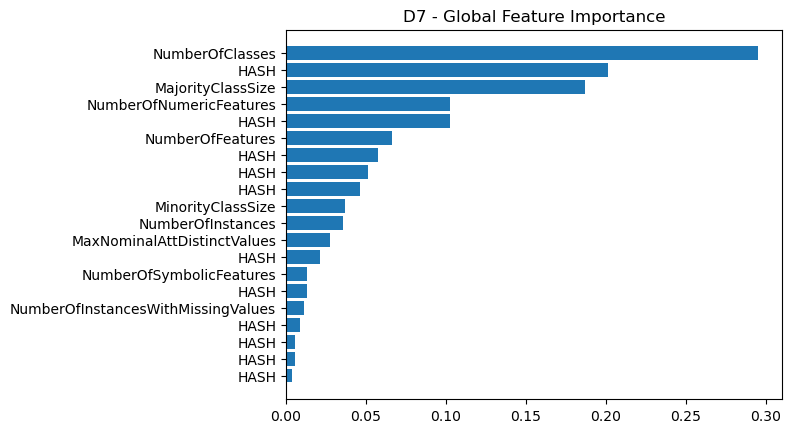

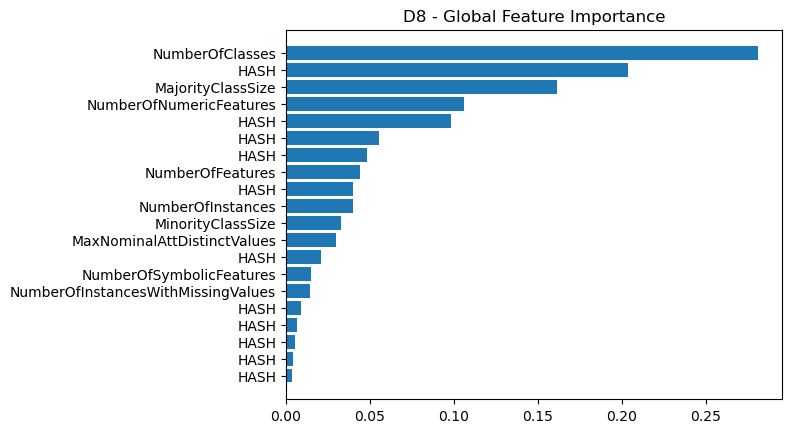

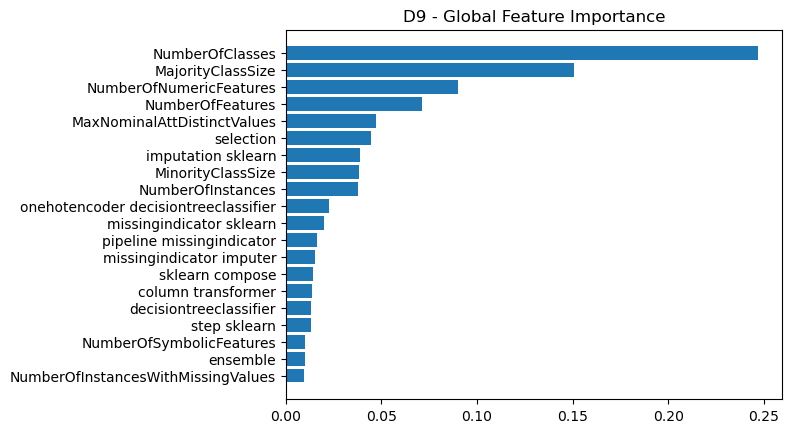

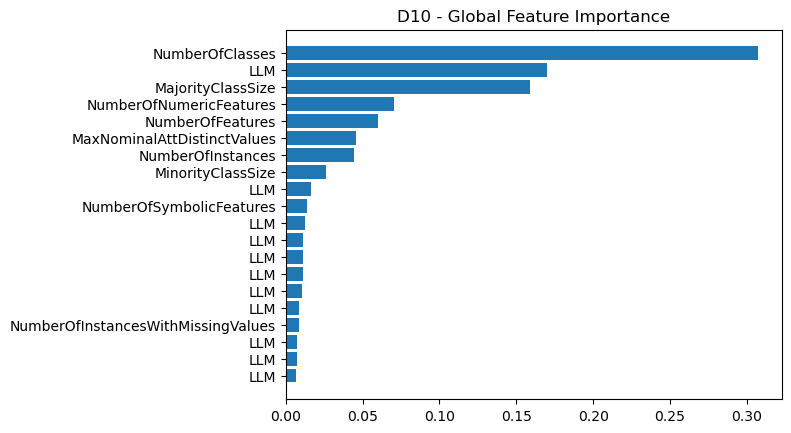

In [136]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

fn = np.concatenate([columns, embed])
reg.fit(X, Y)

perm = permutation_importance(
    reg, X, Y,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn[indices])
plt.title("D1 - Global Feature Importance")
plt.savefig('GFI-D1.png', bbox_inches='tight')
plt.show()


fn2 = np.concatenate([columns, embed2])
reg.fit(X2, Y2)

perm = permutation_importance(
    reg, X2, Y2,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn2[indices])
plt.title("D2 - Global Feature Importance")
plt.savefig('GFI-D2.png', bbox_inches='tight')
plt.show()

fn3 = np.concatenate([columns, embed3])
reg.fit(X3, Y3)

perm = permutation_importance(
    reg, X3, Y3,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn3[indices])
plt.title("D3 - Global Feature Importance")
plt.savefig('GFI-D3.png', bbox_inches='tight')
plt.show()

fn4 = np.concatenate([columns, embed4])
reg.fit(X4, Y4)

perm = permutation_importance(
    reg, X4, Y4,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn4[indices])
plt.title("D4 - Global Feature Importance")
plt.savefig('GFI-D4.png', bbox_inches='tight')
plt.show()

fn5 = np.concatenate([columns, embed5])
reg.fit(X5, Y5)

perm = permutation_importance(
    reg, X5, Y5,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn5[indices])
plt.title("D5 - Global Feature Importance")
plt.savefig('GFI-D5.png', bbox_inches='tight')
plt.show()

fn6 = np.concatenate([columns, embed6])
reg.fit(X6, Y6)

perm = permutation_importance(
    reg, X6, Y6,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn6[indices])
plt.title("D6 - Global Feature Importance")
plt.savefig('GFI-D6.png', bbox_inches='tight')
plt.show()

fn7 = np.concatenate([columns, embed7])
reg.fit(X7, Y7)

perm = permutation_importance(
    reg, X7, Y7,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn7[indices])
plt.title("D7 - Global Feature Importance")
plt.savefig('GFI-D7.png', bbox_inches='tight')
plt.show()

fn8 = np.concatenate([columns, embed8])
reg.fit(X8, Y8)

perm = permutation_importance(
    reg, X8, Y8,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn8[indices])
plt.title("D8 - Global Feature Importance")
plt.savefig('GFI-D8.png', bbox_inches='tight')
plt.show()

fn9 = np.concatenate([columns, embed9])
reg.fit(X9, Y9)

perm = permutation_importance(
    reg, X9, Y9,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn9[indices])
plt.title("D9 - Global Feature Importance")
plt.savefig('GFI-D9.png', bbox_inches='tight')
plt.show()

fna = np.concatenate([columns, embeda])
reg.fit(Xa, Ya)

perm = permutation_importance(
    reg, Xa, Ya,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fna[indices])
plt.title("D10 - Global Feature Importance")
plt.savefig('GFI-D10.png', bbox_inches='tight')
plt.show()




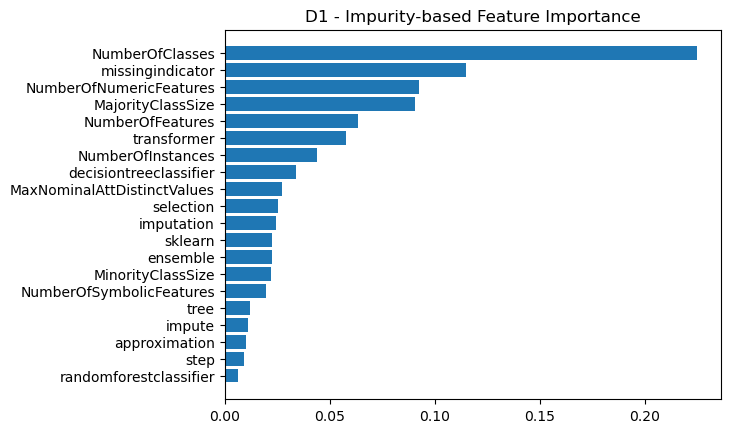

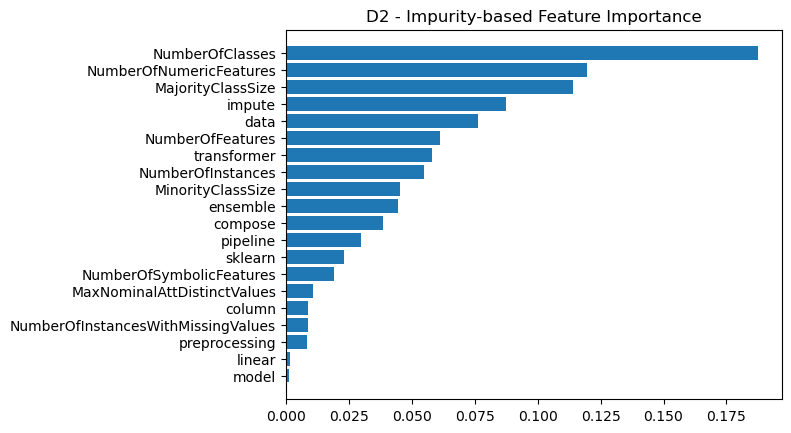

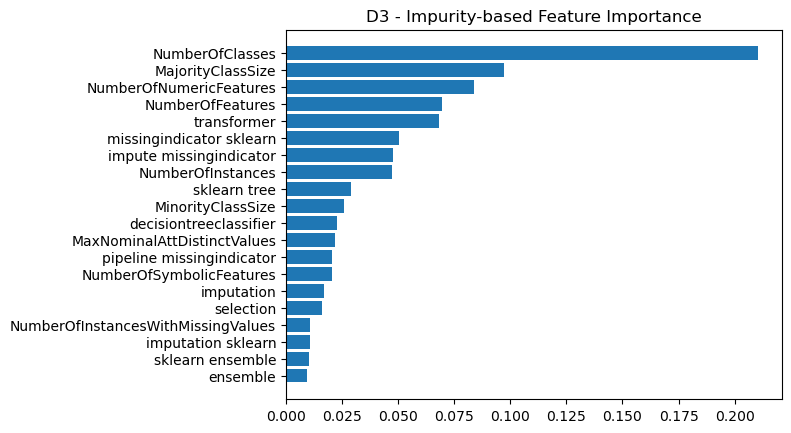

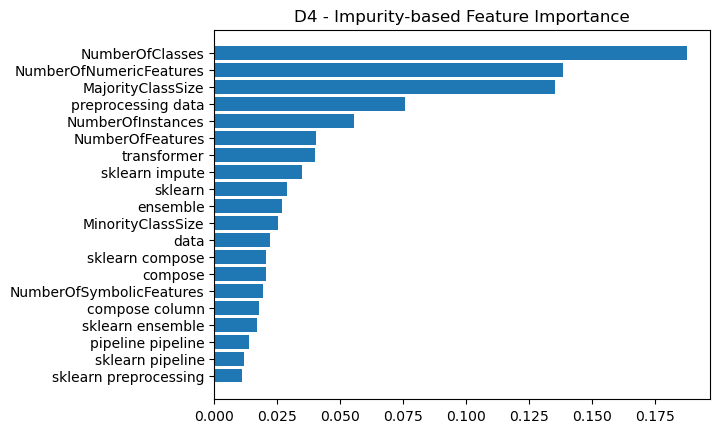

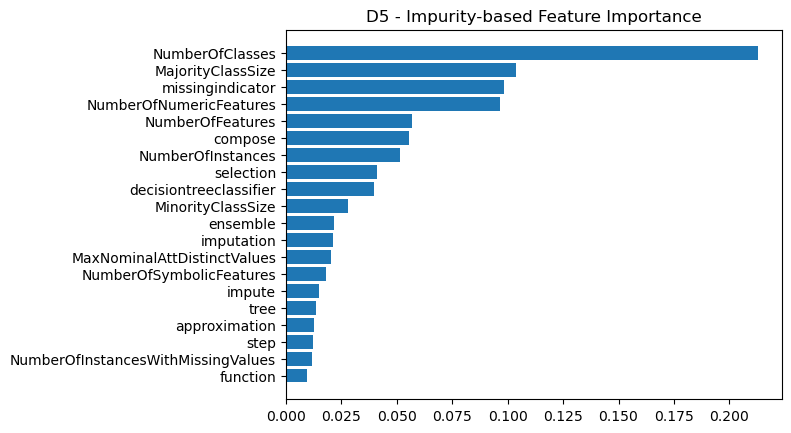

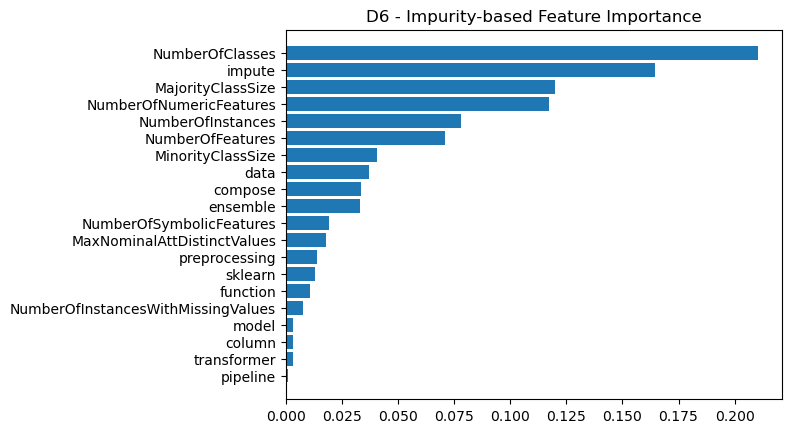

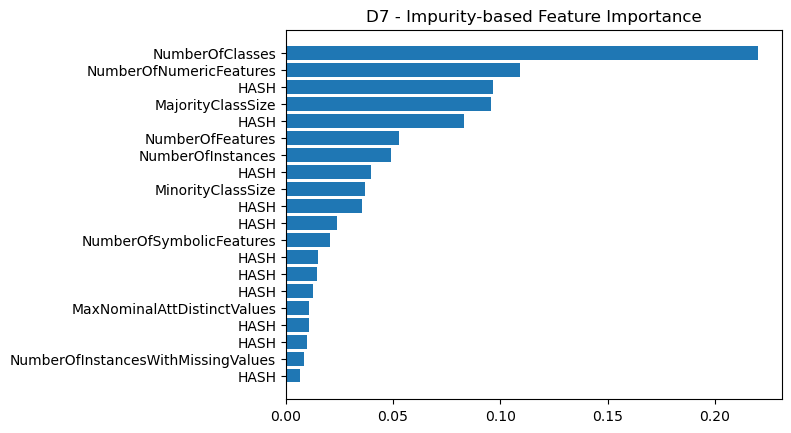

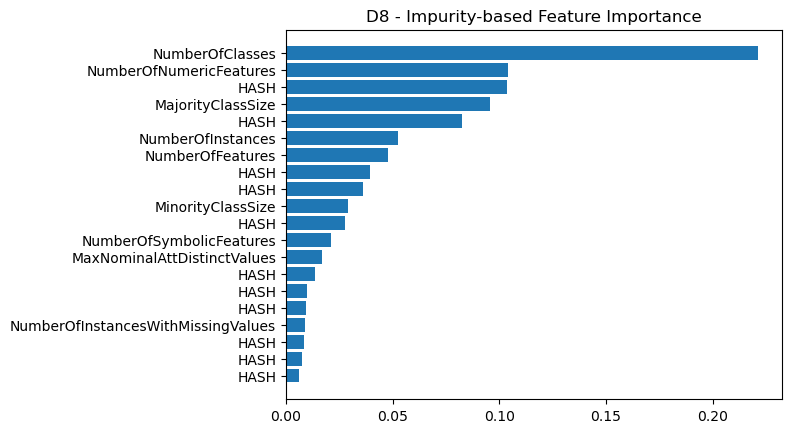

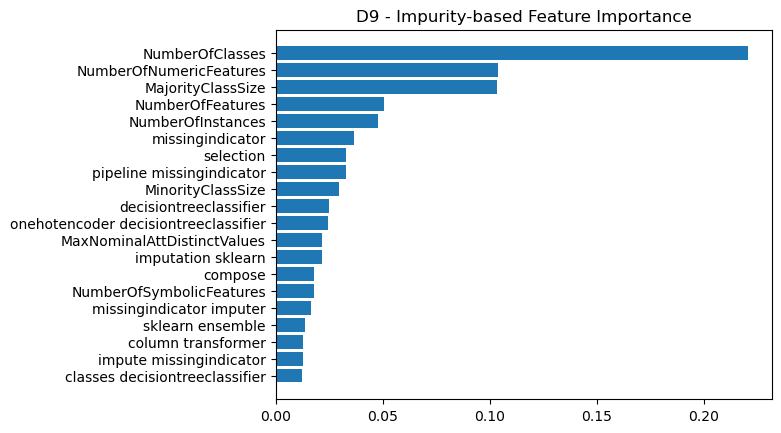

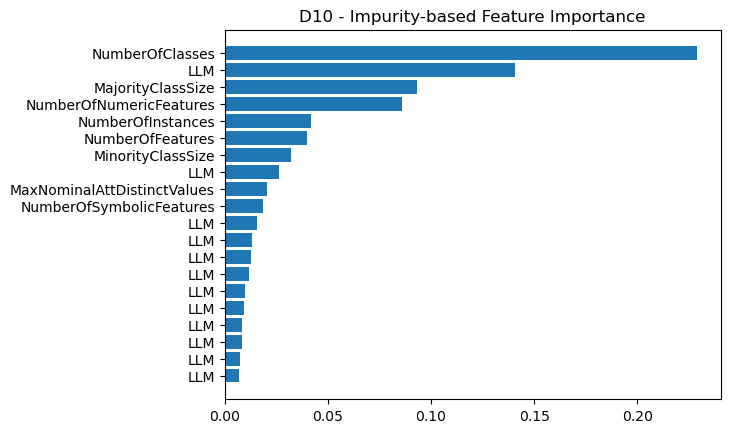

In [135]:

import numpy as np
import matplotlib.pyplot as plt

fn = np.concatenate([columns, embed])
reg.fit(X, Y)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn[indices])
plt.title("D1 - Impurity-based Feature Importance")
plt.savefig('IBI-D1.png', bbox_inches='tight')
plt.show()


fn2 = np.concatenate([columns, embed2])
reg.fit(X2, Y2)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn2[indices])
plt.title("D2 - Impurity-based Feature Importance")
plt.savefig('IBI-D2.png', bbox_inches='tight')
plt.show()

fn3 = np.concatenate([columns, embed3])
reg.fit(X3, Y3)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn3[indices])
plt.title("D3 - Impurity-based Feature Importance")
plt.savefig('IBI-D3.png', bbox_inches='tight')
plt.show()

fn4 = np.concatenate([columns, embed4])
reg.fit(X4, Y4)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn4[indices])
plt.title("D4 - Impurity-based Feature Importance")
plt.savefig('IBI-D4.png', bbox_inches='tight')
plt.show()

fn5 = np.concatenate([columns, embed5])
reg.fit(X5, Y5)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn5[indices])
plt.title("D5 - Impurity-based Feature Importance")
plt.savefig('IBI-D5.png', bbox_inches='tight')
plt.show()

fn6 = np.concatenate([columns, embed6])
reg.fit(X6, Y6)

importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn6[indices])
plt.title("D6 - Impurity-based Feature Importance")
plt.savefig('IBI-D6.png', bbox_inches='tight')
plt.show()

fn7 = np.concatenate([columns, embed7])
reg.fit(X7, Y7)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn7[indices])
plt.title("D7 - Impurity-based Feature Importance")
plt.savefig('IBI-D7.png', bbox_inches='tight')
plt.show()

fn8 = np.concatenate([columns, embed8])
reg.fit(X8, Y8)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn8[indices])
plt.title("D8 - Impurity-based Feature Importance")
plt.savefig('IBI-D8.png', bbox_inches='tight')
plt.show()

fn9 = np.concatenate([columns, embed9])
reg.fit(X9, Y9)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fn9[indices])
plt.title("D9 - Impurity-based Feature Importance")
plt.savefig('IBI-D9.png', bbox_inches='tight')
plt.show()

fna = np.concatenate([columns, embeda])
reg.fit(Xa, Ya)


importances = reg.feature_importances_
indices = np.argsort(importances)[-20:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), fna[indices])
plt.title("D10 - Impurity-based Feature Importance")
plt.savefig('IBI-D10.png', bbox_inches='tight')
plt.show()




In [17]:
import pandas as pd
from itertools import combinations
from scipy.stats import wilcoxon

def pairwise_wilcoxon(results_dict):
    """
    results_dict: dictionary
        keys = model names
        values = arrays of fold-level scores (same length)

    returns pandas dataframe with pairwise comparisons
    """

    rows = []

    for m1, m2 in combinations(results_dict.keys(), 2):
        stat, p = wilcoxon(results_dict[m1], results_dict[m2])

        rows.append({
            "model_A": m1,
            "model_B": m2,
            "wilcoxon_stat": stat,
            "p_value": p
        })

    return pd.DataFrame(rows)



In [18]:
reh = tree.DecisionTreeRegressor()

shoresa = cross_validate(reh, Xa, Ya, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("a")
shores = cross_validate(reh, X, Y, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("1")



a
1


In [ ]:
reh = tree.DecisionTreeRegressor()

shoresa = cross_validate(reh, Xa, Ya, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("a")
shores = cross_validate(reh, X, Y, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("1")
shores2 = cross_validate(reg, X2, Y2, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("2")
shores3 = cross_validate(reg, X3, Y3, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("3")
shores4 = cross_validate(reg, X4, Y4, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("4")
shores5 = cross_validate(reg, X5, Y5, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("5")
shores6 = cross_validate(reg, X6, Y6, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("6")
shores7 = cross_validate(reg, X7, Y7, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("7")
shores8 = cross_validate(reg, X8, Y8, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("8")
shores9 = cross_validate(reg, X9, Y9, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("9")


In [ ]:
shores2 = cross_validate(reg, X2, Y2, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("2")
shores3 = cross_validate(reg, X3, Y3, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("3")
shores4 = cross_validate(reg, X4, Y4, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("4")
shores5 = cross_validate(reg, X5, Y5, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("5")
shores6 = cross_validate(reg, X6, Y6, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("6")
shores7 = cross_validate(reg, X7, Y7, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("7")
shores8 = cross_validate(reg, X8, Y8, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("8")
shores9 = cross_validate(reg, X9, Y9, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("9")

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

fn = np.concatenate([columns, embed])
reg.fit(X, Y)

perm = permutation_importance(
    reg, X, Y,
    n_repeats=10, random_state=42
)

importances = perm.importances_mean
indices = np.argsort(importances)[-20:]


In [13]:
scores = cross_validate(reg, X, Y, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("1")
scores2 = cross_validate(reg, X2, Y2, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("2")
scores3 = cross_validate(reg, X3, Y3, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("3")
scores4 = cross_validate(reg, X4, Y4, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("4")
scores5 = cross_validate(reg, X5, Y5, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("5")
scores6 = cross_validate(reg, X6, Y6, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("6")
scores7 = cross_validate(reg, X7, Y7, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("7")
scores8 = cross_validate(reg, X8, Y8, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("8")
scores9 = cross_validate(reg, X9, Y9, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("9")
scoresa = cross_validate(reg, Xa, Ya, cv=kf,scoring={"R2":sc_r2, "MAE":sc_ma, "MSE":sc_ms}, return_train_score=True)
print("a")

1
2
3
4
5
6
7
8
9
a


In [26]:
results = {
    "TFIDF_R1": scores["test_MSE"],
    "TFIDF_R4": shores["test_MSE"],
    "MiniLM_R1": scoresa["test_MSE"],
    "MiniLM_R4": shoresa["test_MSE"]
}
df = pairwise_wilcoxon(results)
print(df)
df["significant"] = df["p_value"] < 0.05
df.to_csv("wilcoxon_results1.csv", index=False)
print(df.to_latex(index=False))

results = {
    "TFIDF_R1": scores["test_MSE"],
    "TFIDF_R1_margin": scores2["test_MSE"],
    "TFIDF_R1_bigrams": scores3["test_MSE"],
    "TFIDF_R1_margin_bigrams": scores4["test_MSE"]
}
df = pairwise_wilcoxon(results)
print(df)
df["significant"] = df["p_value"] < 0.05
df.to_csv("wilcoxon_results2.csv", index=False)
print(df.to_latex(index=False))

     model_A    model_B  wilcoxon_stat       p_value
0   TFIDF_R1   TFIDF_R4         1198.0  5.051028e-06
1   TFIDF_R1  MiniLM_R1         1830.0  1.686509e-02
2   TFIDF_R1  MiniLM_R4          771.0  1.631280e-09
3   TFIDF_R4  MiniLM_R1         1381.0  8.373749e-05
4   TFIDF_R4  MiniLM_R4           91.0  5.816713e-17
5  MiniLM_R1  MiniLM_R4          558.0  1.349907e-11
\begin{tabular}{llrrr}
\toprule
model_A & model_B & wilcoxon_stat & p_value & significant \\
\midrule
TFIDF_R1 & TFIDF_R4 & 1198.000000 & 0.000005 & True \\
TFIDF_R1 & MiniLM_R1 & 1830.000000 & 0.016865 & True \\
TFIDF_R1 & MiniLM_R4 & 771.000000 & 0.000000 & True \\
TFIDF_R4 & MiniLM_R1 & 1381.000000 & 0.000084 & True \\
TFIDF_R4 & MiniLM_R4 & 91.000000 & 0.000000 & True \\
MiniLM_R1 & MiniLM_R4 & 558.000000 & 0.000000 & True \\
\bottomrule
\end{tabular}

            model_A                  model_B  wilcoxon_stat       p_value
0          TFIDF_R1          TFIDF_R1_margin            4.0  4.397114e-18
1          TFIDF_R1 

In [166]:
import shap
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


def shapbeeswarm(X,Y,name,embed,reg) :

    X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.1, random_state=42)
    fn = np.concatenate([columns, embed])
    reg.fit(X_tr, Y_tr)

    explainer = shap.TreeExplainer(reg)
    shap_values = explainer.shap_values(np.array(X_te))

#shap.plots.waterfall(
#    shap.Explanation(
#        values=shap_values,
#        base_values=explainer.expected_value,
#        data=X_instance[0],
#        feature_names=fn
#    )
#)


    fig = shap.plots.beeswarm(
        shap.Explanation(
            values=shap_values,
            base_values=explainer.expected_value,
            data=np.array(X_te),
            feature_names=fn
        ),show=False
    )
    plt.savefig('shap'+name+'.png',bbox_inches='tight', dpi=300)
    plt.clf()

shapbeeswarm(X,Y,'GBT-1',embed,reg)
shapbeeswarm(X2,Y2,'GBT-2',embed2,reg)
shapbeeswarm(X3,Y3,'GBT-3',embed3,reg)
shapbeeswarm(X4,Y4,'GBT-4',embed4,reg)
shapbeeswarm(X5,Y5,'GBT-5',embed5,reg)
shapbeeswarm(X6,Y6,'GBT-6',embed6,reg)
shapbeeswarm(X7,Y7,'GBT-7',embed7,reg)
shapbeeswarm(X8,Y8,'GBT-8',embed8,reg)
shapbeeswarm(X9,Y9,'GBT-9',embed9,reg)
shapbeeswarm(Xa,Ya,'GBT-10',embeda,reg)



<Figure size 800x550 with 0 Axes>

4665.3955


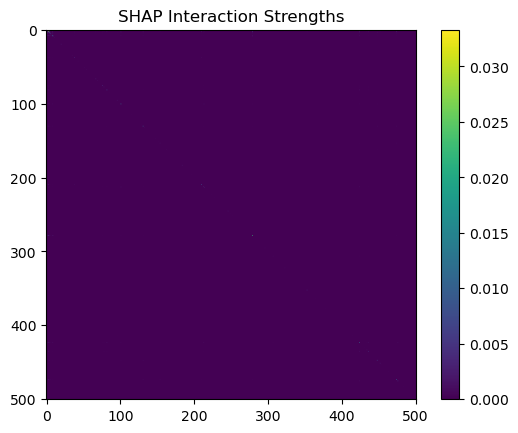

501


In [184]:
import shap
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import xgboost as xgb

reg = xgb.XGBRegressor(
    max_depth=6,
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


def shapexplain(X,Y,name,embed,reg) :

    X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.1, random_state=42)
    fn = np.concatenate([columns, embed])
    reg.fit(X_tr, Y_tr)

    explainer = shap.TreeExplainer(reg)
    shap_values = explainer.shap_values(np.array(X_te))

#shap.plots.waterfall(
#    shap.Explanation(
#        values=shap_values,
#        base_values=explainer.expected_value,
#        data=X_instance[0],
#        feature_names=fn
#    )
#)

    #X_sample = np.array(X_tr).sample(n=1000, random_state=42)
    X_sample = np.array(X_tr)
    shap_interactions = explainer.shap_interaction_values(X_sample)
    print(np.sum(np.abs(shap_interactions)))
    # Aggregate absolute interaction strength
    interaction_strength = np.abs(shap_interactions).mean(axis=0)

    plt.imshow(interaction_strength)
    plt.colorbar()
    plt.title("SHAP Interaction Strengths")
    plt.show()
    return(interaction_strength)


#    plt.savefig('shap'+name+'.png',bbox_inches='tight', dpi=300)
#    plt.clf()

i = shapexplain(X,Y,'1',embed,reg)
print(len(i))



6863.3438


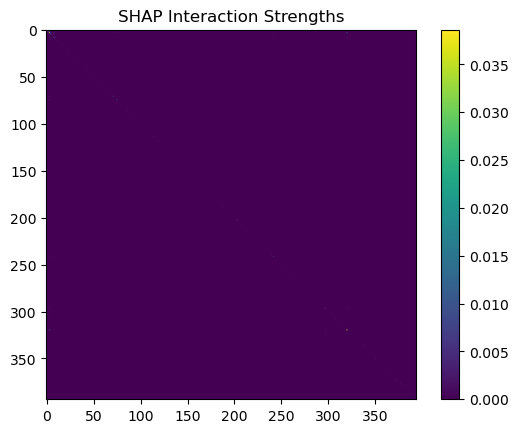

In [191]:
i10 = shapexplain(Xa,Ya,'10',embed,reg)

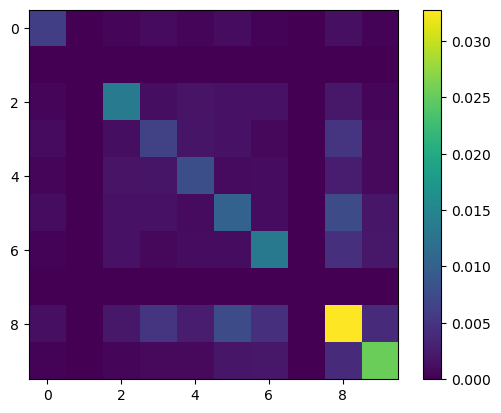

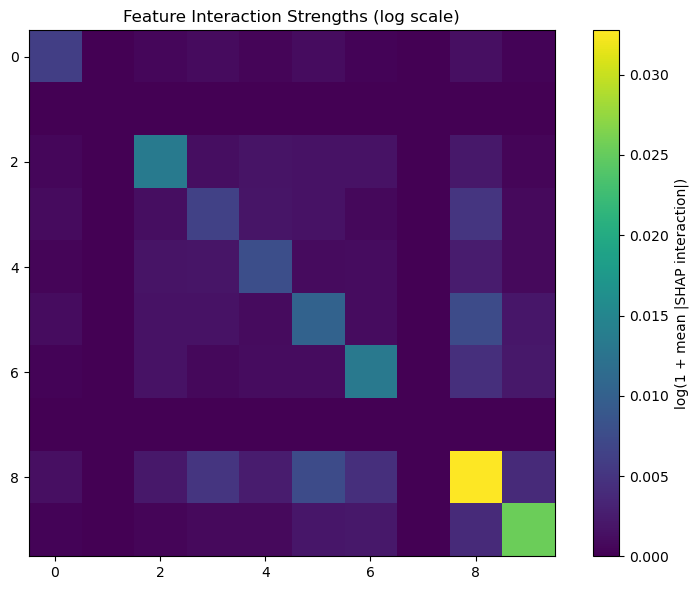

In [192]:
k=10
importance = i10.sum(axis=0)
top_idx = np.argsort(importance)[-k:]

submatrix = i[np.ix_(top_idx, top_idx)]

plt.imshow(np.log1p(submatrix), cmap="viridis")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(
    np.log1p(submatrix),
    cmap="viridis"
)
plt.colorbar(label="log(1 + mean |SHAP interaction|)")
plt.title("Feature Interaction Strengths (log scale)")
plt.tight_layout()
plt.show()

In [22]:
print(scores["test_MSE"])


[0.0180973  0.01541697 0.01359379 0.01692379 0.01642381 0.01701047
 0.0166927  0.01379026 0.01617383 0.01791047 0.01436131 0.0181442
 0.01602036 0.01651946 0.01537206 0.016272   0.01615329 0.01735778
 0.01618436 0.0149886  0.01677289 0.01820988 0.01448949 0.01390612
 0.01938322 0.01414853 0.01970704 0.0147449  0.01833724 0.0144441
 0.01923957 0.01446429 0.01439851 0.01569609 0.01611328 0.01457848
 0.01626214 0.01652649 0.01668508 0.0173407  0.01669712 0.01335926
 0.01745288 0.0135625  0.01610767 0.01864889 0.0178029  0.0129219
 0.01869424 0.01666514 0.01696294 0.01603562 0.01782298 0.01735895
 0.01879219 0.01349309 0.01405992 0.01909948 0.01398448 0.01592229
 0.01647873 0.0187041  0.01313058 0.01524905 0.0171645  0.01451498
 0.01609484 0.01645365 0.02006463 0.01455455 0.01747734 0.01845394
 0.01708909 0.01383754 0.01578217 0.01594749 0.017206   0.0155839
 0.01537938 0.01580514 0.0158792  0.0184238  0.01566093 0.01511228
 0.01588565 0.01744192 0.01261796 0.01640327 0.01913988 0.01605767

In [178]:

print(reg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [59]:
dfc = pd.DataFrame(scores)
print(dfc.mean())
print(dfc.std())

dfc2 = pd.DataFrame(scores2)
print(dfc2.mean())
print(dfc2.std())

dfc3 = pd.DataFrame(scores3)
print(dfc3.mean())
print(dfc3.std())

dfc4 = pd.DataFrame(scores4)
print(dfc4.mean())
print(dfc4.std())

dfc5 = pd.DataFrame(scores5)
print(dfc5.mean())
print(dfc5.std())

dfc6 = pd.DataFrame(scores6)
print(dfc6.mean())
print(dfc6.std())

dfc7 = pd.DataFrame(scores7)
print(dfc7.mean())
print(dfc7.std())

dfc8 = pd.DataFrame(scores8)
print(dfc8.mean())
print(dfc8.std())

dfc9 = pd.DataFrame(scores9)
print(dfc9.mean())
print(dfc9.std())

dfca = pd.DataFrame(scoresa)
print(dfca.mean())
print(dfca.std())

fit_time      8.841067
score_time    0.024104
test_R2       0.773999
train_R2      0.928550
test_MAE      0.041883
train_MAE     0.020762
test_MSE      0.011058
train_MSE     0.003505
dtype: float64
fit_time      0.426898
score_time    0.005004
test_R2       0.039096
train_R2      0.002580
test_MAE      0.003458
train_MAE     0.000382
test_MSE      0.002045
train_MSE     0.000130
dtype: float64
fit_time      1.593821
score_time    0.012274
test_R2       0.665424
train_R2      0.797394
test_MAE      0.060852
train_MAE     0.044926
test_MSE      0.016391
train_MSE     0.009939
dtype: float64
fit_time      0.062346
score_time    0.000855
test_R2       0.044249
train_R2      0.003927
test_MAE      0.004365
train_MAE     0.000598
test_MSE      0.002494
train_MSE     0.000218
dtype: float64
fit_time      26.827821
score_time     0.053693
test_R2        0.783958
train_R2       0.934518
test_MAE       0.041222
train_MAE      0.020130
test_MSE       0.010578
train_MSE      0.003212
dtype: float

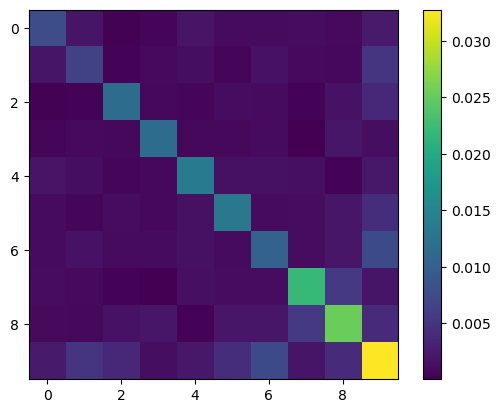

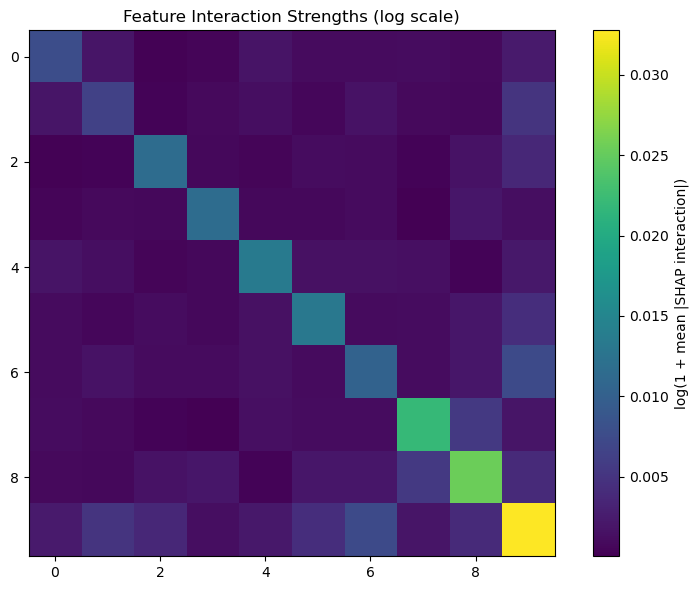

In [190]:
k=10
importance = i.sum(axis=0)
top_idx = np.argsort(importance)[-k:]

submatrix = i[np.ix_(top_idx, top_idx)]

plt.imshow(np.log1p(submatrix), cmap="viridis")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(
    np.log1p(submatrix),
    cmap="viridis"
)
plt.colorbar(label="log(1 + mean |SHAP interaction|)")
plt.title("Feature Interaction Strengths (log scale)")
plt.tight_layout()
plt.show()

In [60]:
s_mse = {k: scores[k] for k in ["test_MSE", "train_MSE"]}
s_mae = {k: scores[k] for k in ["test_MAE", "train_MAE"]}
s_r2 =  {k: scores[k] for k in ["test_R2", "train_R2"]}

s2_mse = {k: scores2[k] for k in ["test_MSE", "train_MSE"]}
s2_mae = {k: scores2[k] for k in ["test_MAE", "train_MAE"]}
s2_r2 =  {k: scores2[k] for k in ["test_R2", "train_R2"]}

s3_mse = {k: scores3[k] for k in ["test_MSE", "train_MSE"]}
s3_mae = {k: scores3[k] for k in ["test_MAE", "train_MAE"]}
s3_r2 =  {k: scores3[k] for k in ["test_R2", "train_R2"]}

s4_mse = {k: scores4[k] for k in ["test_MSE", "train_MSE"]}
s4_mae = {k: scores4[k] for k in ["test_MAE", "train_MAE"]}
s4_r2 =  {k: scores4[k] for k in ["test_R2", "train_R2"]}

s5_mse = {k: scores5[k] for k in ["test_MSE", "train_MSE"]}
s5_mae = {k: scores5[k] for k in ["test_MAE", "train_MAE"]}
s5_r2 =  {k: scores5[k] for k in ["test_R2", "train_R2"]}

s6_mse = {k: scores6[k] for k in ["test_MSE", "train_MSE"]}
s6_mae = {k: scores6[k] for k in ["test_MAE", "train_MAE"]}
s6_r2 =  {k: scores6[k] for k in ["test_R2", "train_R2"]}

s7_mse = {k: scores7[k] for k in ["test_MSE", "train_MSE"]}
s7_mae = {k: scores7[k] for k in ["test_MAE", "train_MAE"]}
s7_r2 =  {k: scores7[k] for k in ["test_R2", "train_R2"]}

s8_mse = {k: scores8[k] for k in ["test_MSE", "train_MSE"]}
s8_mae = {k: scores8[k] for k in ["test_MAE", "train_MAE"]}
s8_r2 =  {k: scores8[k] for k in ["test_R2", "train_R2"]}

s9_mse = {k: scores9[k] for k in ["test_MSE", "train_MSE"]}
s9_mae = {k: scores9[k] for k in ["test_MAE", "train_MAE"]}
s9_r2 =  {k: scores9[k] for k in ["test_R2", "train_R2"]}

sa_mse = {k: scoresa[k] for k in ["test_MSE", "train_MSE"]}
sa_mae = {k: scoresa[k] for k in ["test_MAE", "train_MAE"]}
sa_r2 =  {k: scoresa[k] for k in ["test_R2", "train_R2"]}

In [61]:
D1 = ['D1'] * 100
D2 = ['D2'] * 100
D3 = ['D3'] * 100
D4 = ['D4'] * 100
D5 = ['D5'] * 100
D6 = ['D6'] * 100
D7 = ['D7'] * 100
D8 = ['D8'] * 100
D9 = ['D9'] * 100
Da = ['Da'] * 100

S1 = scores['test_MSE']
S2 = scores2['test_MSE']
S3 = scores3['test_MSE']
S4 = scores4['test_MSE']
S5 = scores5['test_MSE']
S6 = scores6['test_MSE']
S7 = scores7['test_MSE']
S8 = scores8['test_MSE']
S9 = scores9['test_MSE']
Sa = scoresa['test_MSE']


/var/folders/v4/mgpzl55x2p907x9g5_5hh62h0000gn/T/ipykernel_82886/3781941433.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['D1','','D2','','D3','','D4','','D5','','D6','','D7','','D8','','D9','','D0',''])


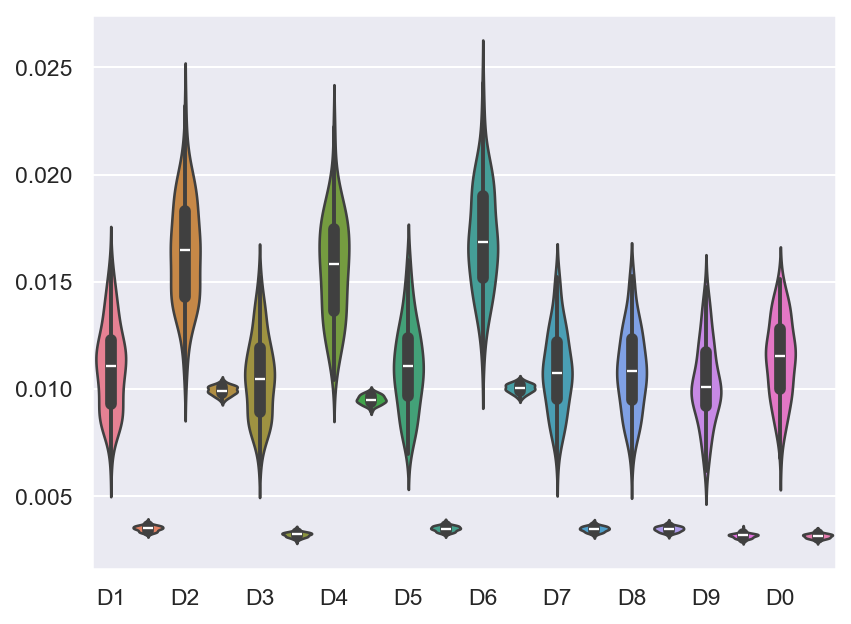

In [62]:
cmse = {}
cmse["D1-te"] = s_mse["test_MSE"]
cmse["D1-tr"] = s_mse["train_MSE"]
cmse["D2-te"] = s2_mse["test_MSE"]
cmse["D2-tr"] = s2_mse["train_MSE"]
cmse["D3-te"] = s3_mse["test_MSE"]
cmse["D3-tr"] = s3_mse["train_MSE"]
cmse["D4-te"] = s4_mse["test_MSE"]
cmse["D4-tr"] = s4_mse["train_MSE"]
cmse["D5-te"] = s5_mse["test_MSE"]
cmse["D5-tr"] = s5_mse["train_MSE"]
cmse["D6-te"] = s6_mse["test_MSE"]
cmse["D6-tr"] = s6_mse["train_MSE"]
cmse["D7-te"] = s7_mse["test_MSE"]
cmse["D7-tr"] = s7_mse["train_MSE"]
cmse["D8-te"] = s8_mse["test_MSE"]
cmse["D8-tr"] = s8_mse["train_MSE"]
cmse["D9-te"] = s9_mse["test_MSE"]
cmse["D9-tr"] = s9_mse["train_MSE"]
cmse["D0-te"] = sa_mse["test_MSE"]
cmse["D0-tr"] = sa_mse["train_MSE"]
df_mse = pd.DataFrame(cmse)

seaborn.set_context("paper", font_scale=0.8)
seaborn.set_theme(rc={"figure.dpi": 150})
ax = seaborn.violinplot(data=df_mse)
ax.set_xticklabels(['D1','','D2','','D3','','D4','','D5','','D6','','D7','','D8','','D9','','D0',''])
plt.savefig("rfr-10cmp.png")

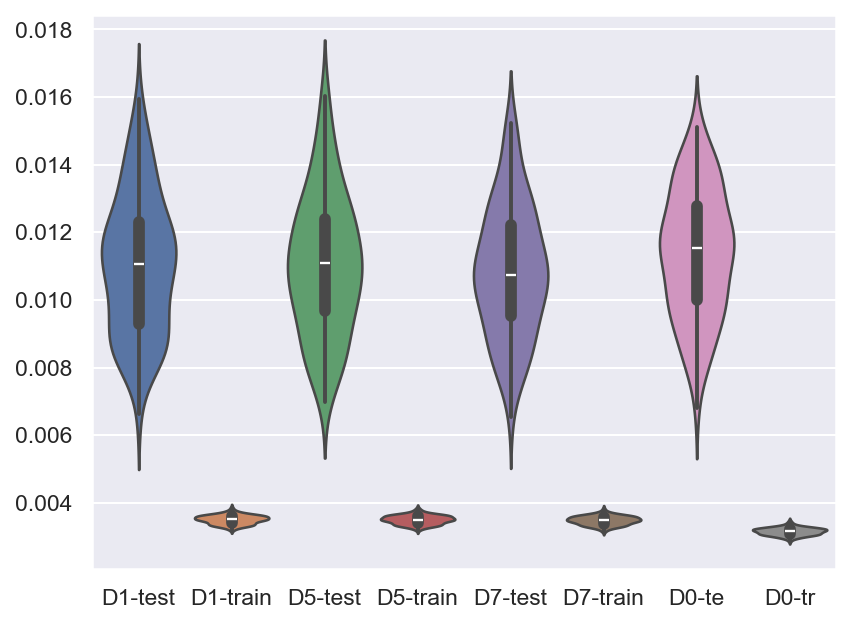

In [63]:
cmse = {}
cmse["D1-test"] = s_mse["test_MSE"]
cmse["D1-train"] = s_mse["train_MSE"]
cmse["D5-test"] = s5_mse["test_MSE"]
cmse["D5-train"] = s5_mse["train_MSE"]
cmse["D7-test"] = s7_mse["test_MSE"]
cmse["D7-train"] = s7_mse["train_MSE"]
cmse["D0-te"] = sa_mse["test_MSE"]
cmse["D0-tr"] = sa_mse["train_MSE"]
df_mse = pd.DataFrame(cmse)

seaborn.set_theme(rc={"figure.dpi": 150})
seaborn.violinplot(data=df_mse)
plt.savefig("rfr-main4-cmp.png")

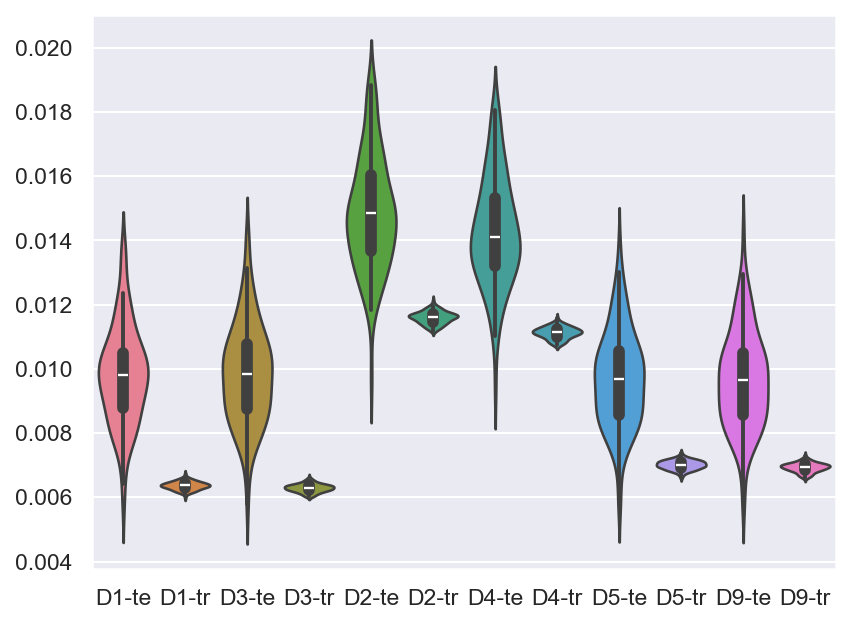

In [44]:
cmse = {}
cmse["D1-te"] = s_mse["test_MSE"]
cmse["D1-tr"] = s_mse["train_MSE"]
cmse["D3-te"] = s3_mse["test_MSE"]
cmse["D3-tr"] = s3_mse["train_MSE"]
cmse["D2-te"] = s2_mse["test_MSE"]
cmse["D2-tr"] = s2_mse["train_MSE"]
cmse["D4-te"] = s4_mse["test_MSE"]
cmse["D4-tr"] = s4_mse["train_MSE"]
cmse["D5-te"] = s5_mse["test_MSE"]
cmse["D5-tr"] = s5_mse["train_MSE"]
cmse["D9-te"] = s9_mse["test_MSE"]
cmse["D9-tr"] = s9_mse["train_MSE"]
df_mse = pd.DataFrame(cmse)

seaborn.set_theme(rc={"figure.dpi": 150})
seaborn.violinplot(data=df_mse)
plt.savefig("hgbr-bigrams-cmp.png")

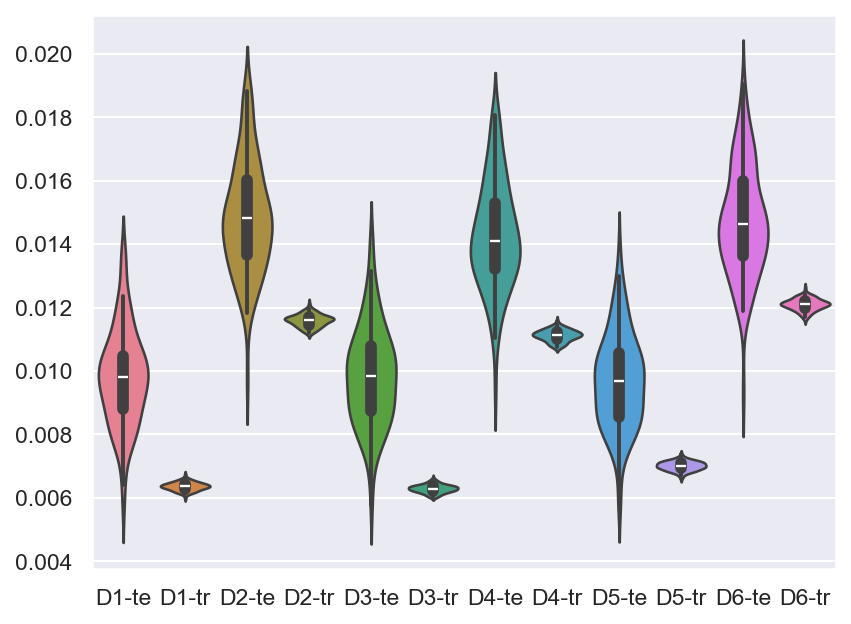

In [45]:
cmse = {}
cmse["D1-te"] = s_mse["test_MSE"]
cmse["D1-tr"] = s_mse["train_MSE"]
cmse["D2-te"] = s2_mse["test_MSE"]
cmse["D2-tr"] = s2_mse["train_MSE"]
cmse["D3-te"] = s3_mse["test_MSE"]
cmse["D3-tr"] = s3_mse["train_MSE"]
cmse["D4-te"] = s4_mse["test_MSE"]
cmse["D4-tr"] = s4_mse["train_MSE"]
cmse["D5-te"] = s5_mse["test_MSE"]
cmse["D5-tr"] = s5_mse["train_MSE"]
cmse["D6-te"] = s6_mse["test_MSE"]
cmse["D6-tr"] = s6_mse["train_MSE"]
df_mse = pd.DataFrame(cmse)

seaborn.set_theme(rc={"figure.dpi": 150})
seaborn.violinplot(data=df_mse)
plt.savefig("hgbr-smaller.png")

In [182]:
from sklearn.metrics import mean_absolute_error

Y_pred = reg.predict(X_te)
print("MAE:", mean_absolute_error(Y_te, Y_pred))

print(shap_interactions)

plt.figure(figsize=(8, 6))
plt.imshow(
    np.log1p(shap_interactions),
    cmap="viridis"
)
plt.colorbar(label="log(1 + mean |SHAP interaction|)")
plt.title("Feature Interaction Strengths (log scale)")
plt.tight_layout()
plt.show()

MAE: 0.05849801376461983


NameError: name 'shap_interactions' is not defined

In [ ]:
seaborn.set_theme(rc={"figure.dpi": 150})
seaborn.set_style("white")
D1 = [1] * 100
D2 = [3] * 100
TR = [0] * 200
TE = [1] * 200
S1 = list(scores['test_MSE'])
S2 = list(scores3['test_MSE'])
T1 = list(scores['train_MSE'])
T2 = list(scores3['train_MSE'])

NIC = [0] *400

D = D1 + D2 + D1 + D2
S = S1 + S2 + T1 + T2
T = TR + TE

dfmse = pd.DataFrame({'MSE': S, 'dataset':D, 'train': T, 'nic': NIC})
#seaborn.violinplot(data=dfmse, hue='dataset',  palette="muted", x='train',y='MSE', split=True, inner="quart", fill=False)
seaborn.violinplot(data=dfmse,  palette="muted", hue='dataset',x='train',y='MSE', split=True, inner="quart", fill=False)
#seaborn.violinplot(data=dfmse, split=True)

In [ ]:
D1 = [1] * 100
D2 = [2] * 100
TR = [0] * 200
TE = [1] * 200
S1 = list(scores['test_MAE'])
S2 = list(scores2['test_MAE'])
T1 = list(scores['train_MAE'])
T2 = list(scores2['train_MAE'])

NIC = [0] *400

D = D1 + D2 + D1 + D2
S = S1 + S2 + T1 + T2
T = TR + TE

dfmse = pd.DataFrame({'MAE': S, 'dataset':D, 'train': T, 'nic': NIC})
seaborn.violinplot(data=dfmse, palette="muted", hue='dataset',x='train',y='MAE', split=True, inner="quart", fill=False)

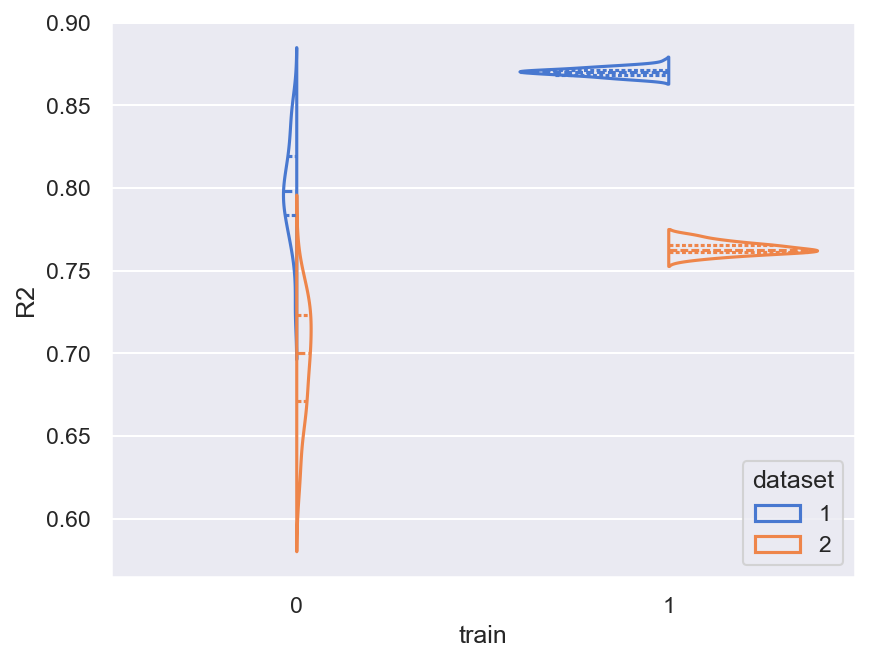

In [50]:
D1 = [1] * 100
D2 = [2] * 100
TR = [0] * 200
TE = [1] * 200
S1 = list(scores['test_R2'])
S2 = list(scores2['test_R2'])
T1 = list(scores['train_R2'])
T2 = list(scores2['train_R2'])

NIC = [0] *400

D = D1 + D2 + D1 + D2
S = S1 + S2 + T1 + T2
T = TR + TE

dfmse = pd.DataFrame({'R2': S, 'dataset':D, 'train': T, 'nic': NIC})
ax = seaborn.violinplot(data=dfmse, palette="muted", hue='dataset',x='train',y='R2', split=True, inner="quart", fill=False)
seaborn.move_legend(ax,'lower right')

In [ ]:

df_mse = pd.DataFrame(s_mse)
seaborn.violinplot(data=df_mse)

In [ ]:
df_mae = pd.DataFrame(s_mae)
seaborn.violinplot(data=df_mae)

In [ ]:
df_r2 = pd.DataFrame(s_r2)
seaborn.violinplot(data=df_r2)

In [ ]:
df2_mse = pd.DataFrame(s2_mse)
seaborn.violinplot(data=df2_mse)

In [ ]:
df2_mae = pd.DataFrame(s2_mae)
seaborn.violinplot(data=df2_mae)

In [ ]:
df2_r2 = pd.DataFrame(s2_r2)
seaborn.violinplot(data=df2_r2)

In [ ]:
#reg = linear_model.LinearRegression()
#reg = linear_model.SGDRegressor()
#reg = svm.NuSVR(kernel='rbf')
#reg = tree.DecisionTreeRegressor()
#reg = ensemble.RandomForestRegressor()
#reg = ensemble.ExtraTreesRegressor()
#reg = gaussian_process.GaussianProcessRegressor()
#reg = ensemble.AdaBoostRegressor(tree.DecisionTreeRegressor(), n_estimators=500)
reg = ensemble.HistGradientBoostingRegressor()
#reg = neural_network.MLPRegressor(hidden_layer_sizes=(500,500,500,500),max_iter=1000)
#reg = ensemble.GradientBoostingRegressor()
y_pred = reg.fit(X_train, y_train).predict(X_test)
y_predt = reg.fit(X_train, y_train).predict(X_train)
r2 = sklearn.metrics.r2_score(y_test, y_pred)
print(r2)
r2t = sklearn.metrics.r2_score(y_train, y_predt)
print(r2t)

In [3]:
# No data processing required
# Create diagram using matplotlib / graphviz

from graphviz import Digraph

dot = Digraph()

dot.node("D", "Dataset\nMeta-features")
dot.node("W", "Workflow\nText")
dot.node("E", "Encoding\n(TF-IDF / MiniLM)")
dot.node("M", "Meta-model\n(GBDT)")
dot.node("P", "Prediction")
dot.node("X", "Explanation\n(SHAP, CF)")

dot.edges([("D","E"), ("W","E"), ("E","M"), ("M","P"), ("M","X")])
dot


ModuleNotFoundError: No module named 'graphviz'